# 4.5 Descriptive & Univariate Analysis
## Pre-Modeling Diagnostics: Distributions, Boxplots, and Consistency Checks

This notebook runs **before** the hypothesis-testing notebooks (5, 6).
It produces the descriptive statistics, histograms, and boxplots that
ground interpretation of the models.

**Sections:**
1. Setup & Data Loading
2. Data Transformation (derive party_3, FNR, long format, etc.)
3. Sample Overview
4. Histograms: Base-Rate Beliefs (FPR, TPR) by theme & party
5. Histograms: Error Thresholds (log_ratio) by theme & party
6. Distribution Statistics Table (mean, median, skew, kurtosis)
7. Boxplots: d', c, log_ratio, preference by party × theme
8. Logical Inconsistency in Base-Rate Calculations
9. Below-Diagonal Operating Points
10. Political vs Non-Political & FP-worse vs FN-worse Bundling

## 1. Setup & Data Loading

In [1]:
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = '/content/drive/My Drive/Projects/SDT/Data/cleaned_data.csv'
SAVE_DIR = '/content/drive/My Drive/Projects/SDT/Data/descriptive/'

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
from scipy import stats as sp_stats
from scipy.stats import norm, ttest_ind, mannwhitneyu, kurtosis, skew
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
})

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")

Loaded: 670 rows × 541 columns


## 2. Data Transformation

Derives variables needed for descriptive analysis that are not in the
cleaned CSV: `party_3`, `party_binary`, `party_centered`, `{theme}_fnr`,
and the respondent × theme long-format dataset.

In [3]:
"""
Data Transformation for Descriptive Analysis
=============================================
Derives: party_3, party_binary, party_centered, ideology_centered,
         {theme}_fnr, and respondent × theme long-format dataset.

Attention filter: passes_attention == 1 (from cleaning pipeline).
"""

# =====================================================================
# CONSTANTS
# =====================================================================
THEMES = ['disease', 'armed', 'conv', 'welfare', 'immi',
          'vote', 'air', 'firearm', 'auto']

THEME_NAMES = {
    'disease': 'Disease Testing',    'armed': 'Armed Conflict',
    'conv': 'Criminal Justice',      'welfare': 'Welfare',
    'immi': 'Immigration',           'vote': 'Voting / Voter ID',
    'air': 'Airport Security',       'firearm': 'Firearms',
    'auto': 'Autonomous Driving',
}

THEME_VALENCE = {
    'disease': 'neutral',   'armed': 'conservative', 'conv': 'conservative',
    'welfare': 'liberal',   'immi': 'conservative',  'vote': 'conservative',
    'air': 'neutral',       'firearm': 'liberal',    'auto': 'neutral',
}

THEME_PREF_MAP = {
    'armed': 'hawk_scale',       'conv': 'pref_crime_rec',
    'welfare': 'pref_work_rec',  'immi': 'pref_imm_rec',
    'vote': 'pref_id_rec',      'air': 'civlib_scale',
    'firearm': 'pref_guns_rec',
}

# Issue groupings
POLITICAL_THEMES = [t for t, v in THEME_VALENCE.items() if v != 'neutral']
NONPOLITICAL_THEMES = [t for t, v in THEME_VALENCE.items() if v == 'neutral']

# FP-worse vs FN-worse (from R perspective):
#   FN-worse = R thinks letting bad actors through is worse (miss-averse)
#   FP-worse = R thinks wrongly restricting someone is worse (FP-averse)
R_FN_WORSE = ['armed', 'conv', 'immi', 'vote']  # R wants to catch threats
R_FP_WORSE = ['firearm']                          # R wants to protect gun access
# welfare is liberal-valenced so R actually wants to deny (FN = letting ineligible through)
# but from the survey framing, R is FN-averse on welfare too (catch ineligible)
# We'll note this nuance in the analysis

PARTY_COLORS = {
    'Democrat': '#1a5276',      # darker blue for visibility
    'Independent': '#6c6c6c',
    'Republican': '#922b21',    # darker red for visibility
}

PARTY_COLORS_LIGHT = {
    'Democrat': '#5dade2',
    'Independent': '#aeb6bf',
    'Republican': '#ec7063',
}

# =====================================================================
# DERIVE WIDE-FORMAT VARIABLES
# =====================================================================

# --- Party categorical ---
df['party_3'] = pd.cut(
    df['party_id_7'], bins=[0, 3, 4, 7],
    labels=['Democrat', 'Independent', 'Republican']
)
df['party_binary'] = np.where(
    df['party_id_7'] <= 3, 'Democrat',
    np.where(df['party_id_7'] >= 5, 'Republican', 'Independent')
)
df['party_centered'] = df['party_id_7'] - df['party_id_7'].mean()
df['ideology_centered'] = df['ideology_num'] - df['ideology_num'].mean()

# --- FNR (= 1 - TPR) ---
for theme in THEMES:
    tpr_col = f'{theme}_tpr'
    fnr_col = f'{theme}_fnr'
    if tpr_col in df.columns and fnr_col not in df.columns:
        df[fnr_col] = 1.0 - df[tpr_col]

# --- Attention filter ---
def get_mask(df):
    """Primary attention filter from cleaning pipeline."""
    return df['passes_attention'] == 1

mask = get_mask(df)
print(f"Attention filter: {mask.sum()} / {len(df)} pass")
print(f"  Excluded: {(~mask).sum()}")

# =====================================================================
# BUILD LONG-FORMAT DATA
# =====================================================================

def build_long(df, use_attentive=True):
    """
    Reshape to respondent × theme long format.
    One row per participant per theme they were assigned.
    """
    if use_attentive:
        df = df[get_mask(df)].copy()

    rows = []
    for idx, row in df.iterrows():
        resp_id = row.get('ResponseId', idx)
        for theme in THEMES:
            fpr = row.get(f'{theme}_fpr')
            tpr = row.get(f'{theme}_tpr')
            # Skip themes not assigned (both FPR and TPR missing)
            if pd.isna(fpr) and pd.isna(tpr):
                continue

            pref_var = THEME_PREF_MAP.get(theme)
            r = {
                'respondent_id': resp_id,
                'theme': theme,
                'theme_name': THEME_NAMES[theme],
                'valence': THEME_VALENCE[theme],
                'fpr': fpr,
                'tpr': tpr,
                'fnr': row.get(f'{theme}_fnr'),
                'd_prime': row.get(f'{theme}_d_prime'),
                'c_sdt': row.get(f'{theme}_c'),
                'can_sdt': row.get(f'{theme}_can_sdt'),
                'consistency_sum': row.get(f'{theme}_consistency_sum'),
                'consistency_deviation': row.get(f'{theme}_consistency_deviation'),
                'log_ratio': row.get(f'{theme}_err_log_ratio'),
                'log_ratio_aligned': row.get(f'{theme}_err_log_ratio_aligned'),
                'err_choice': row.get(f'{theme}_err_choice'),
                'preference': row.get(pref_var) if pref_var else np.nan,
                'party_id_7': row.get('party_id_7'),
                'party_3': row.get('party_3'),
                'party_binary': row.get('party_binary'),
                'ideology_num': row.get('ideology_num'),
                'B_before_T': row.get('B_before_T'),
                'BT_before_P': row.get('BT_before_P'),
            }
            rows.append(r)

    long = pd.DataFrame(rows)

    # Z-score preference within theme
    long['preference_z'] = long.groupby('theme')['preference'].transform(
        lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0
    )

    # Below-diagonal flag: FPR > TPR means worse than chance
    long['below_diagonal'] = (long['fpr'] > long['tpr']).astype(int)

    return long

long = build_long(df, use_attentive=True)
n_resp = long['respondent_id'].nunique()
print(f"\nLong-format: {len(long)} obs from {n_resp} participants")
print(f"  with d_prime: {long['d_prime'].notna().sum()}")
print(f"  with log_ratio: {long['log_ratio'].notna().sum()}")
print(f"  with preference: {long['preference'].notna().sum()}")

Attention filter: 649 / 670 pass
  Excluded: 21

Long-format: 4543 obs from 649 participants
  with d_prime: 4363
  with log_ratio: 3325
  with preference: 3560


## 3. Sample Overview

In [4]:
print("=" * 60)
print("SAMPLE OVERVIEW (attentive participants)")
print("=" * 60)

att = df[get_mask(df)]
print(f"\nN = {len(att)}")

print(f"\n--- Party ID (3-category) ---")
print(att['party_3'].value_counts().sort_index())

print(f"\n--- Party ID (7-point) ---")
print(att['party_id_7'].value_counts().sort_index())

print(f"\n--- Ideology (7-point) ---")
print(att['ideology_num'].value_counts().sort_index())

print(f"\n--- Demographics ---")
print(f"  Age: M={att['age'].mean():.1f}, SD={att['age'].std():.1f}, "
      f"range={att['age'].min():.0f}–{att['age'].max():.0f}")
print(f"  Gender: {att['gender_clean'].value_counts().to_dict()}")
print(f"  Education (1–7): M={att['education_num'].mean():.1f}, "
      f"Median={att['education_num'].median():.0f}")

print(f"\n--- Experimental Conditions ---")
print(f"  Order: {att['order'].value_counts().to_dict()}")
print(f"  B_before_T: {att['B_before_T'].value_counts().to_dict()}")
print(f"  BT_before_P: {att['BT_before_P'].value_counts().to_dict()}")

print(f"\n--- Themes per participant ---")
print(f"  M={att['total_themes_answered'].mean():.1f}, "
      f"Median={att['total_themes_answered'].median():.0f}")

# Party × ideology cross-tab
print(f"\n--- Party × Ideology Means ---")
party_ideo = att.groupby('party_3')['ideology_num'].agg(['mean','std','count'])
print(party_ideo.round(2))

SAMPLE OVERVIEW (attentive participants)

N = 649

--- Party ID (3-category) ---
party_3
Democrat       343
Independent     79
Republican     227
Name: count, dtype: int64

--- Party ID (7-point) ---
party_id_7
1    165
2    101
3     77
4     79
5     48
6     82
7     97
Name: count, dtype: int64

--- Ideology (7-point) ---
ideology_num
1     99
2    142
3     68
4    134
5     69
6    102
7     35
Name: count, dtype: int64

--- Demographics ---
  Age: M=38.2, SD=12.8, range=18–79
  Gender: {'Male': 335, 'Female': 313, 'Other': 1}
  Education (1–7): M=4.4, Median=5

--- Experimental Conditions ---
  Order: {'PBT': 187, 'BTP': 159, 'TBP': 159, 'PTB': 144}
  B_before_T: {1.0: 346, 0.0: 303}
  BT_before_P: {0.0: 331, 1.0: 318}

--- Themes per participant ---
  M=7.0, Median=7

--- Party × Ideology Means ---
             mean   std  count
party_3                       
Democrat     2.39  1.29    343
Independent  3.82  0.98     79
Republican   5.30  1.31    227


Party–Ideology correlation: r = 0.747, p = 0.0000


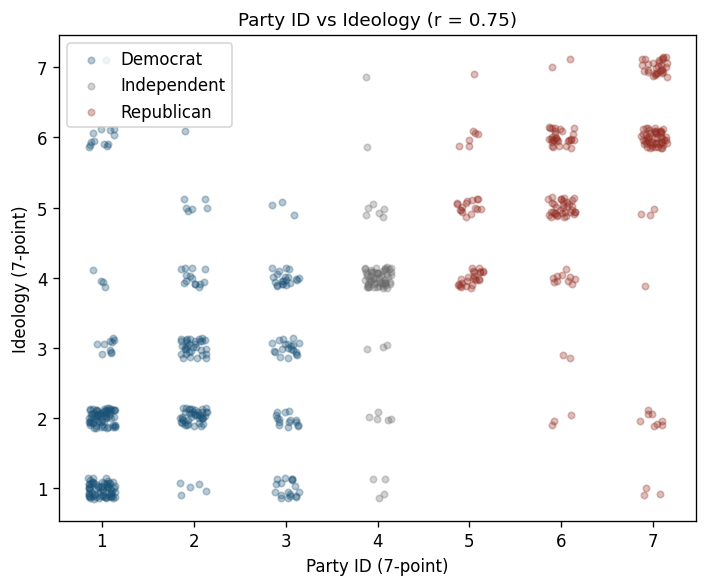

In [5]:
# Correlation between party_id_7 and ideology_num
r, p = sp_stats.pearsonr(att['party_id_7'], att['ideology_num'])
print(f"Party–Ideology correlation: r = {r:.3f}, p = {p:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
for party in ['Democrat', 'Independent', 'Republican']:
    pdata = att[att['party_3'] == party]
    ax.scatter(pdata['party_id_7'] + np.random.uniform(-0.15, 0.15, len(pdata)),
               pdata['ideology_num'] + np.random.uniform(-0.15, 0.15, len(pdata)),
               c=PARTY_COLORS[party], alpha=0.3, s=15, label=party)
ax.set_xlabel('Party ID (7-point)')
ax.set_ylabel('Ideology (7-point)')
ax.set_title(f'Party ID vs Ideology (r = {r:.2f})')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Histograms: Base-Rate Beliefs (FPR, TPR) by Theme & Party

These show where participants think each policy classifier is operating:
how many false positives and true positives they believe occur out of 1,000.

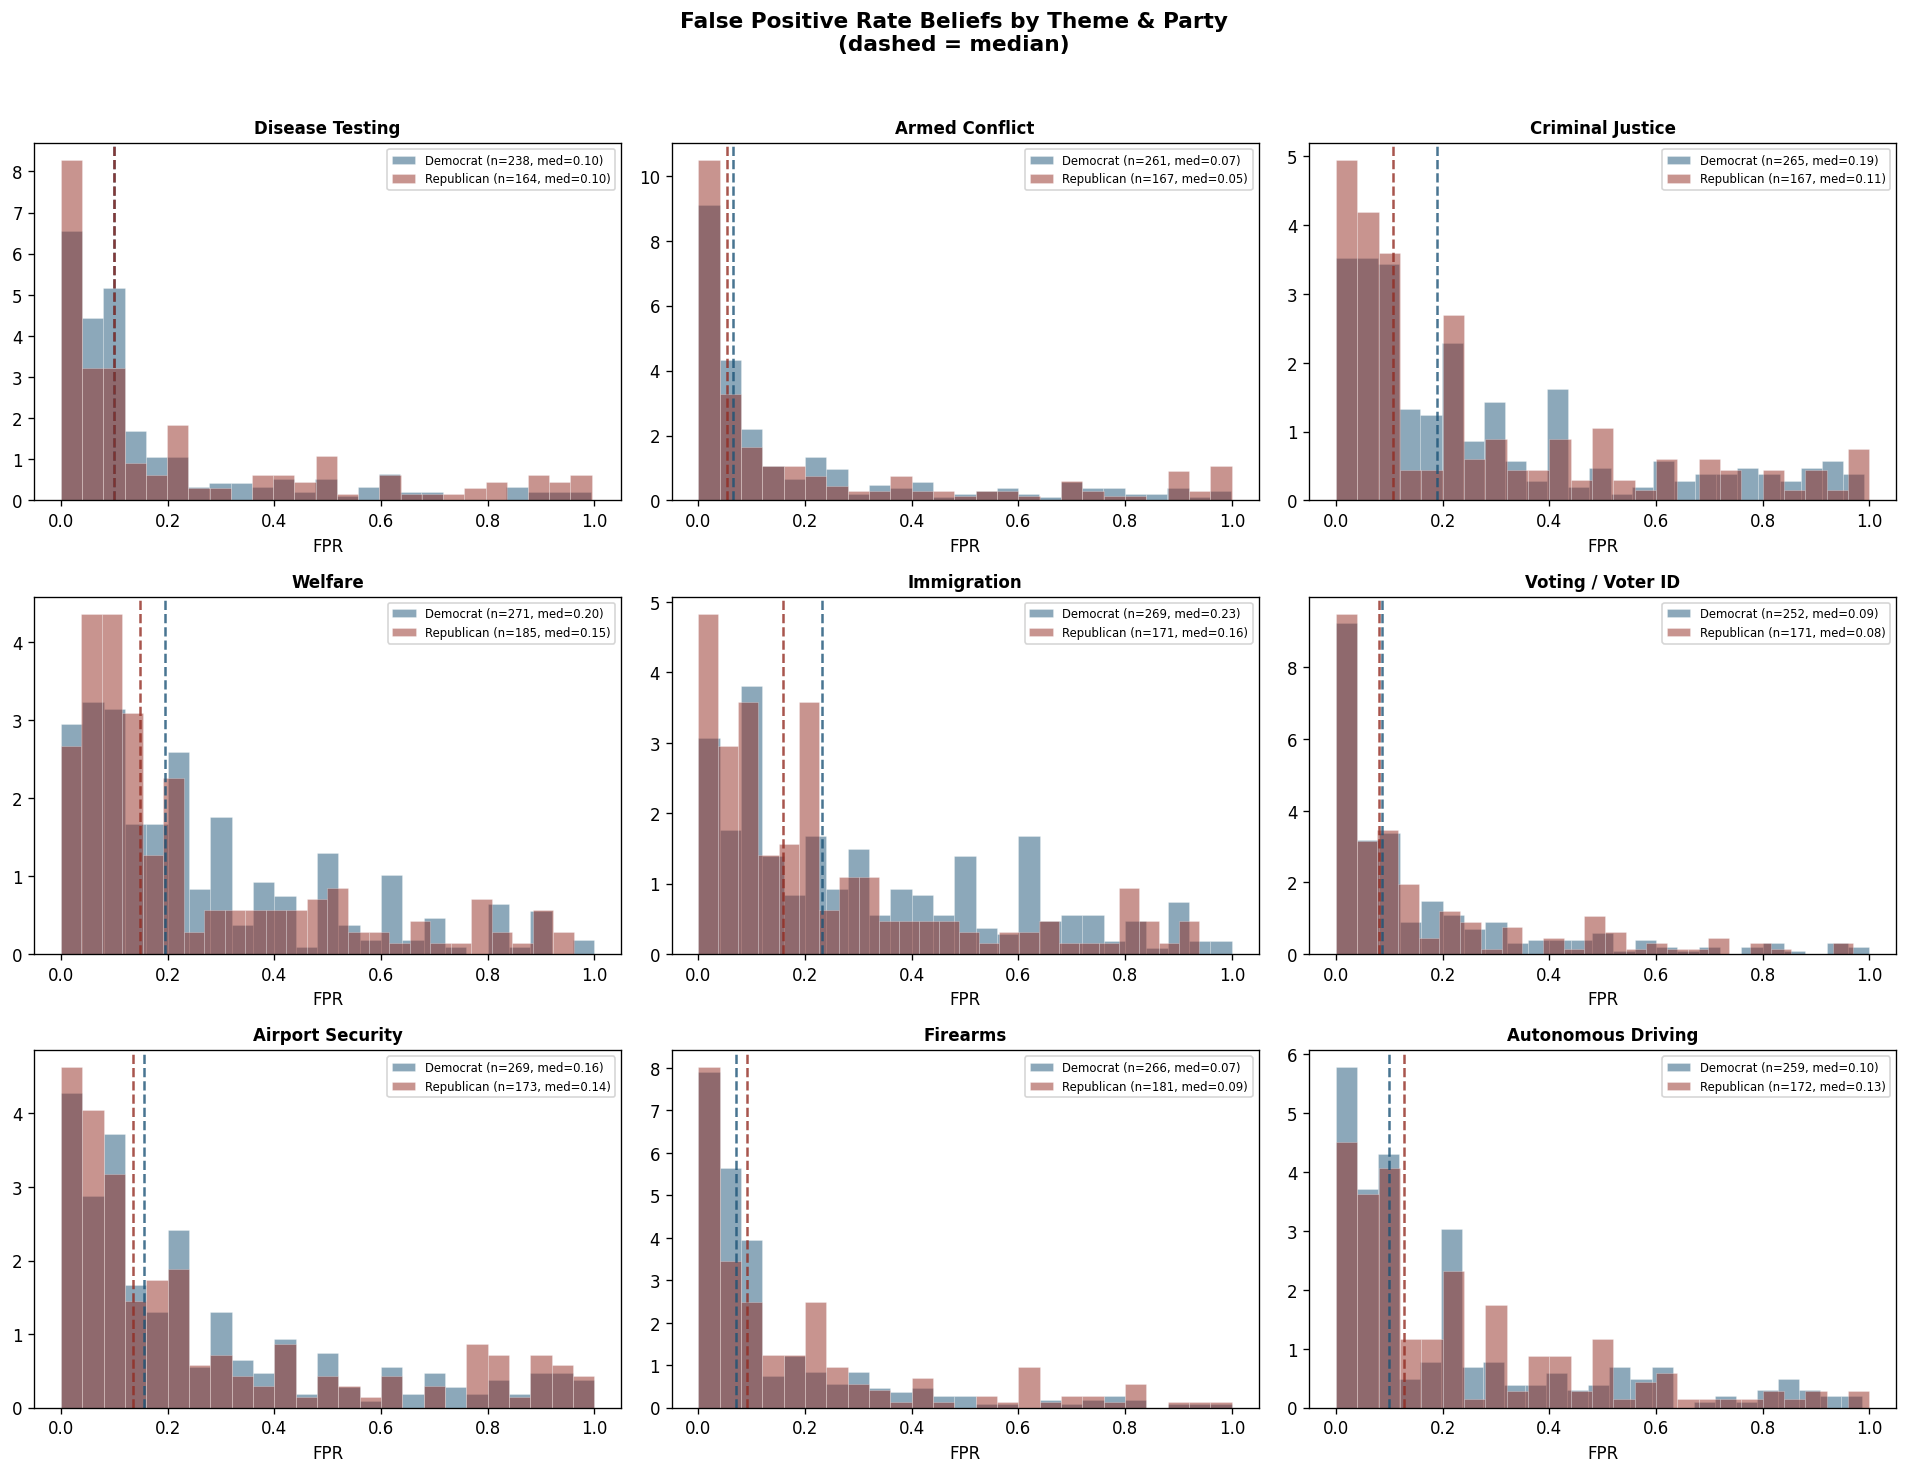

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, theme in enumerate(THEMES):
    ax = axes[i]
    td = long[long['theme'] == theme].dropna(subset=['fpr'])

    for party in ['Democrat', 'Republican']:
        pdata = td[td['party_binary'] == party]['fpr']
        if len(pdata) > 0:
            ax.hist(pdata, bins=25, alpha=0.5, color=PARTY_COLORS[party],
                    label=f'{party} (n={len(pdata)}, med={pdata.median():.2f})',
                    density=True, edgecolor='white', linewidth=0.3)
            ax.axvline(pdata.median(), color=PARTY_COLORS[party],
                       linestyle='--', linewidth=1.5, alpha=0.8)

    ax.set_title(THEME_NAMES[theme], fontweight='bold', fontsize=10)
    ax.set_xlabel('FPR')
    ax.set_xlim(-0.05, 1.05)
    ax.legend(fontsize=7)

fig.suptitle('False Positive Rate Beliefs by Theme & Party\n(dashed = median)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

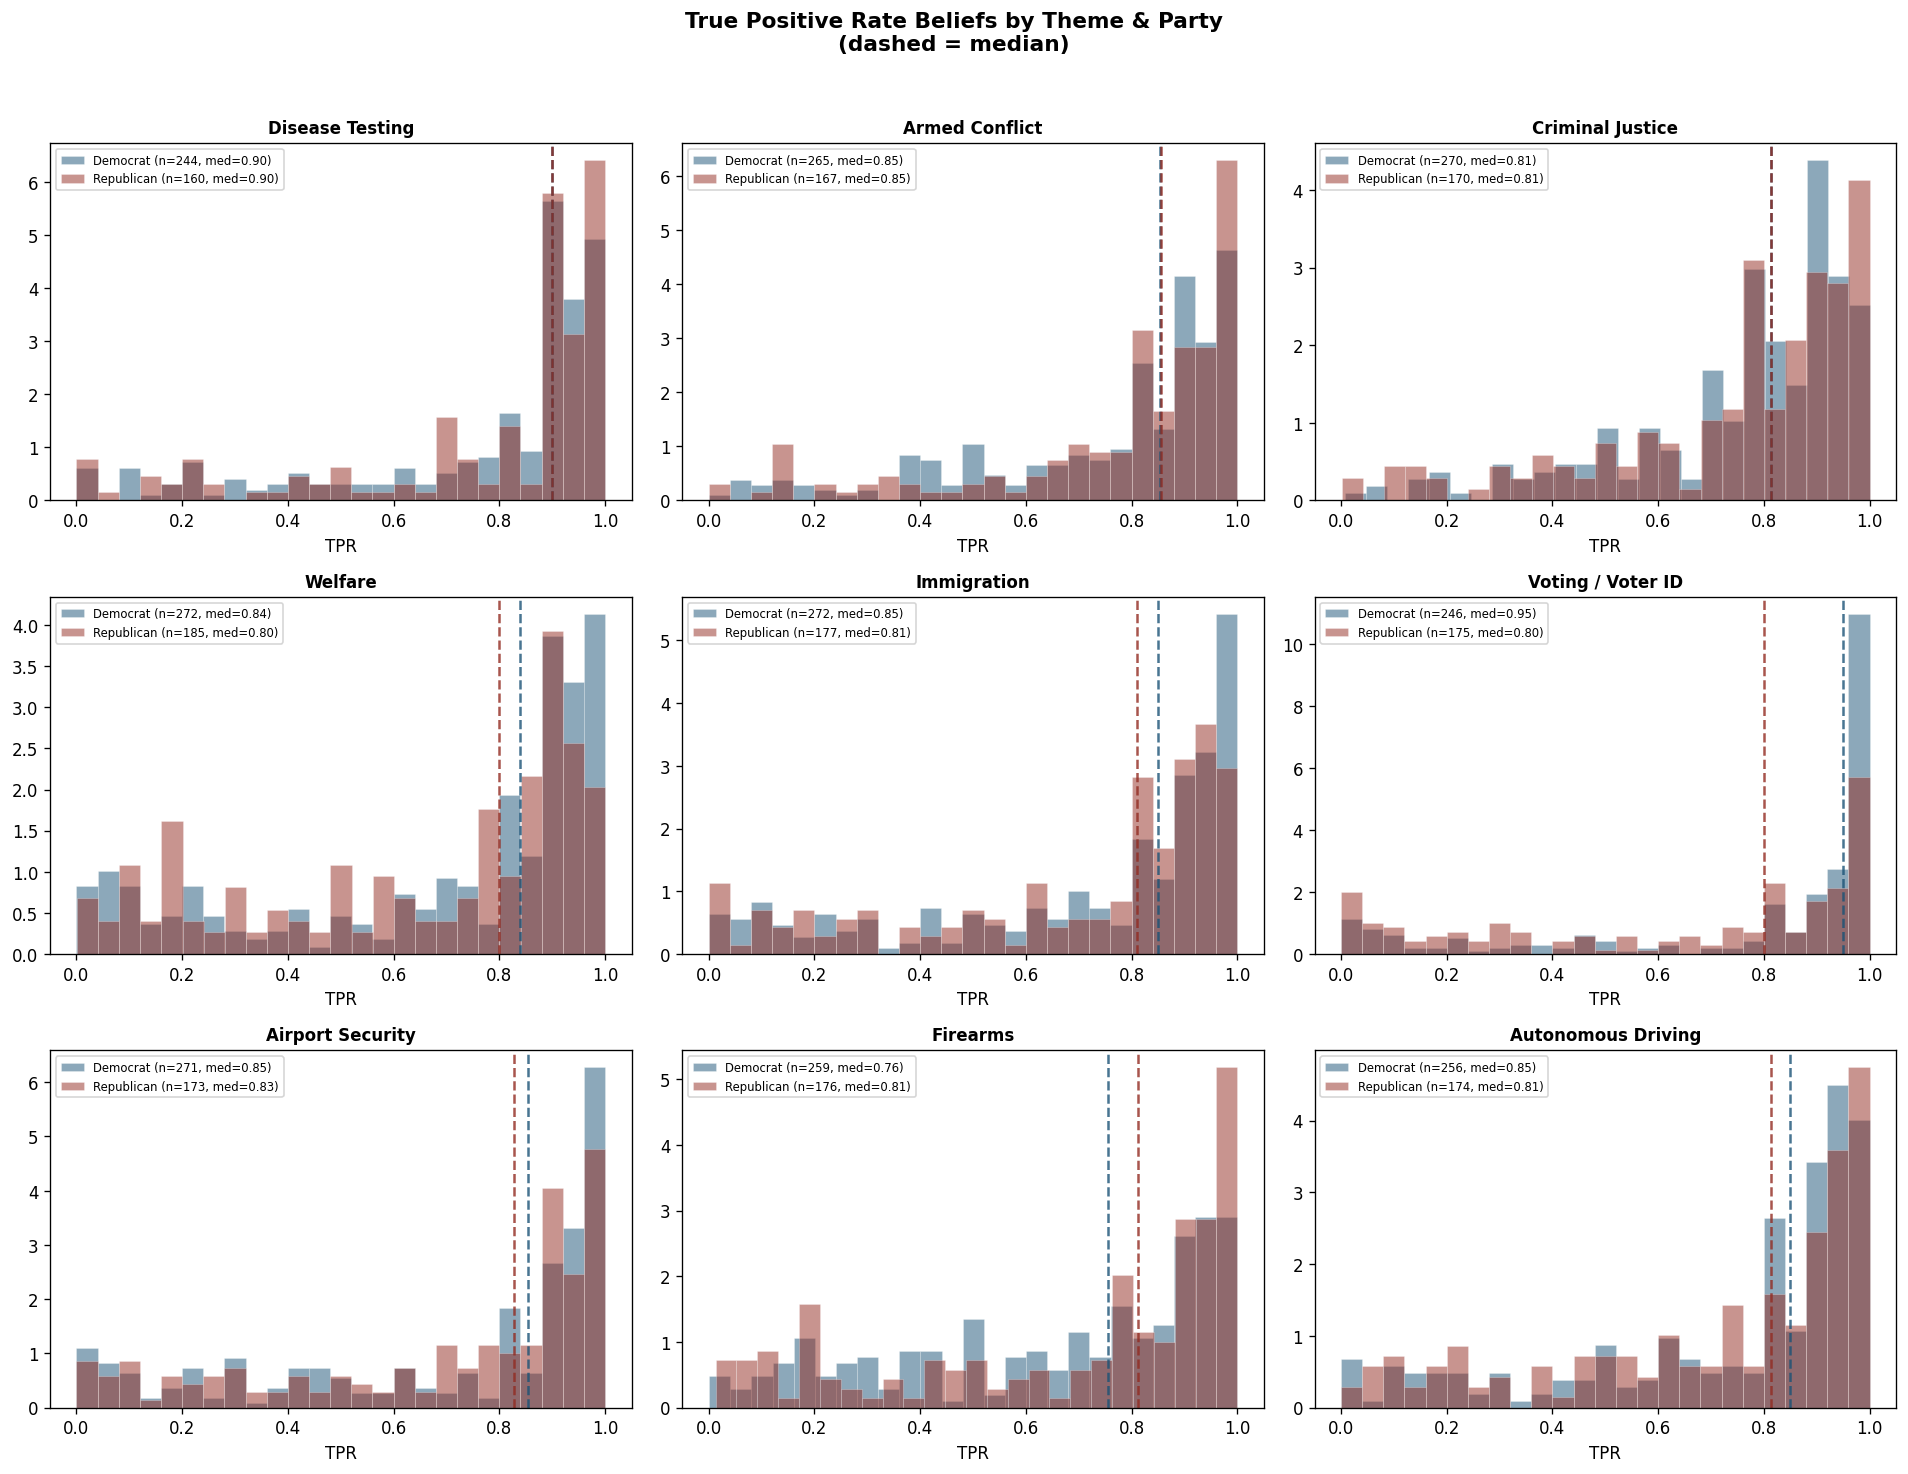

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, theme in enumerate(THEMES):
    ax = axes[i]
    td = long[long['theme'] == theme].dropna(subset=['tpr'])

    for party in ['Democrat', 'Republican']:
        pdata = td[td['party_binary'] == party]['tpr']
        if len(pdata) > 0:
            ax.hist(pdata, bins=25, alpha=0.5, color=PARTY_COLORS[party],
                    label=f'{party} (n={len(pdata)}, med={pdata.median():.2f})',
                    density=True, edgecolor='white', linewidth=0.3)
            ax.axvline(pdata.median(), color=PARTY_COLORS[party],
                       linestyle='--', linewidth=1.5, alpha=0.8)

    ax.set_title(THEME_NAMES[theme], fontweight='bold', fontsize=10)
    ax.set_xlabel('TPR')
    ax.set_xlim(-0.05, 1.05)
    ax.legend(fontsize=7)

fig.suptitle('True Positive Rate Beliefs by Theme & Party\n(dashed = median)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Histograms: Error Thresholds (log_ratio) by Theme & Party

`log_ratio` = log10(FP:FN tolerance ratio).
Positive = miss-averse (accept FP to avoid FN).
Negative = FP-averse (accept FN to avoid FP).

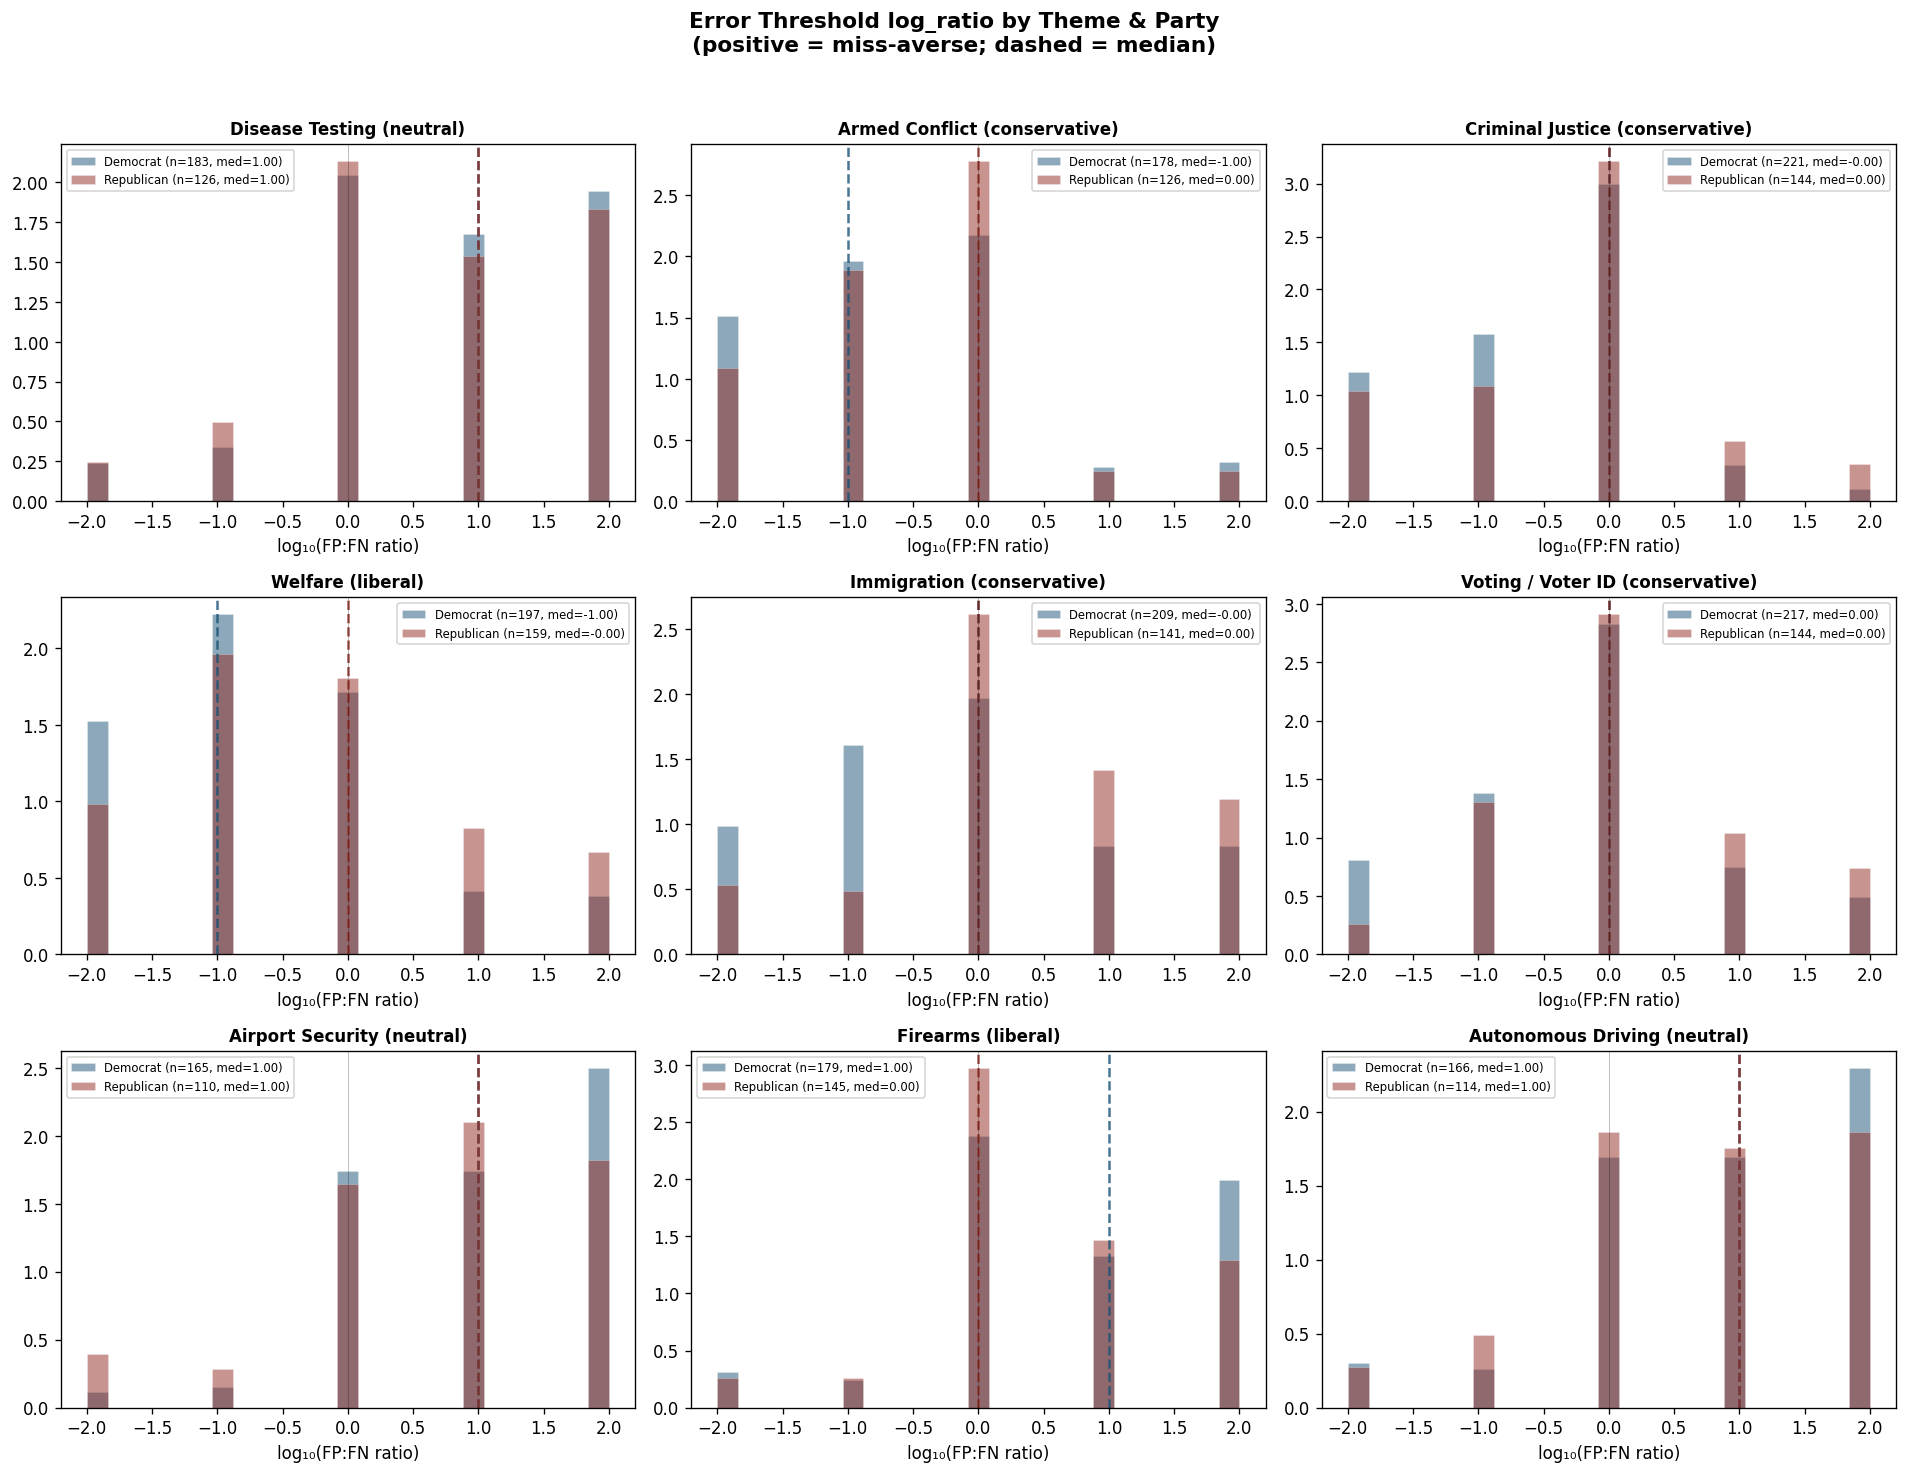

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, theme in enumerate(THEMES):
    ax = axes[i]
    td = long[long['theme'] == theme].dropna(subset=['log_ratio'])

    for party in ['Democrat', 'Republican']:
        pdata = td[td['party_binary'] == party]['log_ratio']
        if len(pdata) > 0:
            ax.hist(pdata, bins=25, alpha=0.5, color=PARTY_COLORS[party],
                    label=f'{party} (n={len(pdata)}, med={pdata.median():.2f})',
                    density=True, edgecolor='white', linewidth=0.3)
            ax.axvline(pdata.median(), color=PARTY_COLORS[party],
                       linestyle='--', linewidth=1.5, alpha=0.8)

    ax.axvline(0, color='black', linewidth=0.5, alpha=0.3)
    ax.set_title(f"{THEME_NAMES[theme]} ({THEME_VALENCE[theme]})",
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('log₁₀(FP:FN ratio)')
    ax.legend(fontsize=7)

fig.suptitle('Error Threshold log_ratio by Theme & Party\n'
             '(positive = miss-averse; dashed = median)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Distribution Statistics Table

Mean, median, SD, skewness, kurtosis, and n for each variable by theme.

In [9]:
print("=" * 100)
print("DISTRIBUTION STATISTICS BY THEME (attentive participants)")
print("=" * 100)

metrics = [
    ('fpr', 'FPR'),
    ('tpr', 'TPR'),
    ('d_prime', "d'"),
    ('c_sdt', 'c (criterion)'),
    ('log_ratio', 'log_ratio'),
]

for var, label in metrics:
    print(f"\n{'─' * 100}")
    print(f"  {label}")
    print(f"{'─' * 100}")
    print(f"  {'Theme':<20} {'n':>5} {'Mean':>8} {'Median':>8} {'SD':>8} "
          f"{'Skew':>8} {'Kurt':>8} {'Min':>8} {'Max':>8}")
    print(f"  {'─'*88}")

    for theme in THEMES:
        td = long[(long['theme'] == theme)][var].dropna()
        if len(td) < 3:
            continue
        print(f"  {THEME_NAMES[theme]:<20} {len(td):>5} {td.mean():>8.3f} "
              f"{td.median():>8.3f} {td.std():>8.3f} "
              f"{skew(td):>8.2f} {kurtosis(td):>8.2f} "
              f"{td.min():>8.3f} {td.max():>8.3f}")

    # Grand (all themes pooled)
    all_vals = long[var].dropna()
    if len(all_vals) > 0:
        print(f"  {'POOLED':<20} {len(all_vals):>5} {all_vals.mean():>8.3f} "
              f"{all_vals.median():>8.3f} {all_vals.std():>8.3f} "
              f"{skew(all_vals):>8.2f} {kurtosis(all_vals):>8.2f} "
              f"{all_vals.min():>8.3f} {all_vals.max():>8.3f}")

DISTRIBUTION STATISTICS BY THEME (attentive participants)

────────────────────────────────────────────────────────────────────────────────────────────────────
  FPR
────────────────────────────────────────────────────────────────────────────────────────────────────
  Theme                    n     Mean   Median       SD     Skew     Kurt      Min      Max
  ────────────────────────────────────────────────────────────────────────────────────────
  Disease Testing        466    0.187    0.100    0.244     1.80     2.41    0.000    1.000
  Armed Conflict         485    0.191    0.057    0.270     1.68     1.65    0.000    1.000
  Criminal Justice       489    0.262    0.157    0.274     1.24     0.47    0.000    1.000
  Welfare                517    0.258    0.165    0.250     1.25     0.61    0.000    1.000
  Immigration            495    0.280    0.199    0.262     0.98    -0.12    0.000    1.000
  Voting / Voter ID      487    0.164    0.080    0.219     1.86     2.98    0.000    1.00

In [10]:
# --- By party within theme ---
print("\n" + "=" * 100)
print("DISTRIBUTION STATISTICS BY THEME × PARTY")
print("=" * 100)

for var, label in [('d_prime', "d'"), ('c_sdt', 'c'), ('log_ratio', 'log_ratio')]:
    print(f"\n{'─' * 110}")
    print(f"  {label}")
    print(f"{'─' * 110}")
    print(f"  {'Theme':<20} {'Party':<12} {'n':>5} {'Mean':>8} {'Median':>8} "
          f"{'SD':>8} {'Skew':>8} {'Kurt':>8}")
    print(f"  {'─'*80}")

    for theme in THEMES:
        for party in ['Democrat', 'Republican']:
            td = long[(long['theme'] == theme) &
                       (long['party_binary'] == party)][var].dropna()
            if len(td) < 3:
                continue
            print(f"  {THEME_NAMES[theme]:<20} {party:<12} {len(td):>5} "
                  f"{td.mean():>8.3f} {td.median():>8.3f} {td.std():>8.3f} "
                  f"{skew(td):>8.2f} {kurtosis(td):>8.2f}")


DISTRIBUTION STATISTICS BY THEME × PARTY

──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  d'
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Theme                Party            n     Mean   Median       SD     Skew     Kurt
  ────────────────────────────────────────────────────────────────────────────────
  Disease Testing      Democrat       235    2.219    2.563    1.633    -0.41    -0.22
  Disease Testing      Republican     158    2.228    2.563    2.087    -0.35    -0.06
  Armed Conflict       Democrat       258    2.247    2.492    1.830    -0.29    -0.54
  Armed Conflict       Republican     163    2.338    2.658    2.082    -0.48     0.64
  Criminal Justice     Democrat       261    1.687    1.751    1.529    -0.05    -0.49
  Criminal Justice     Republican     166    1.852    1.959    1.897    -0.54     1.34
  Welfare              Democrat       

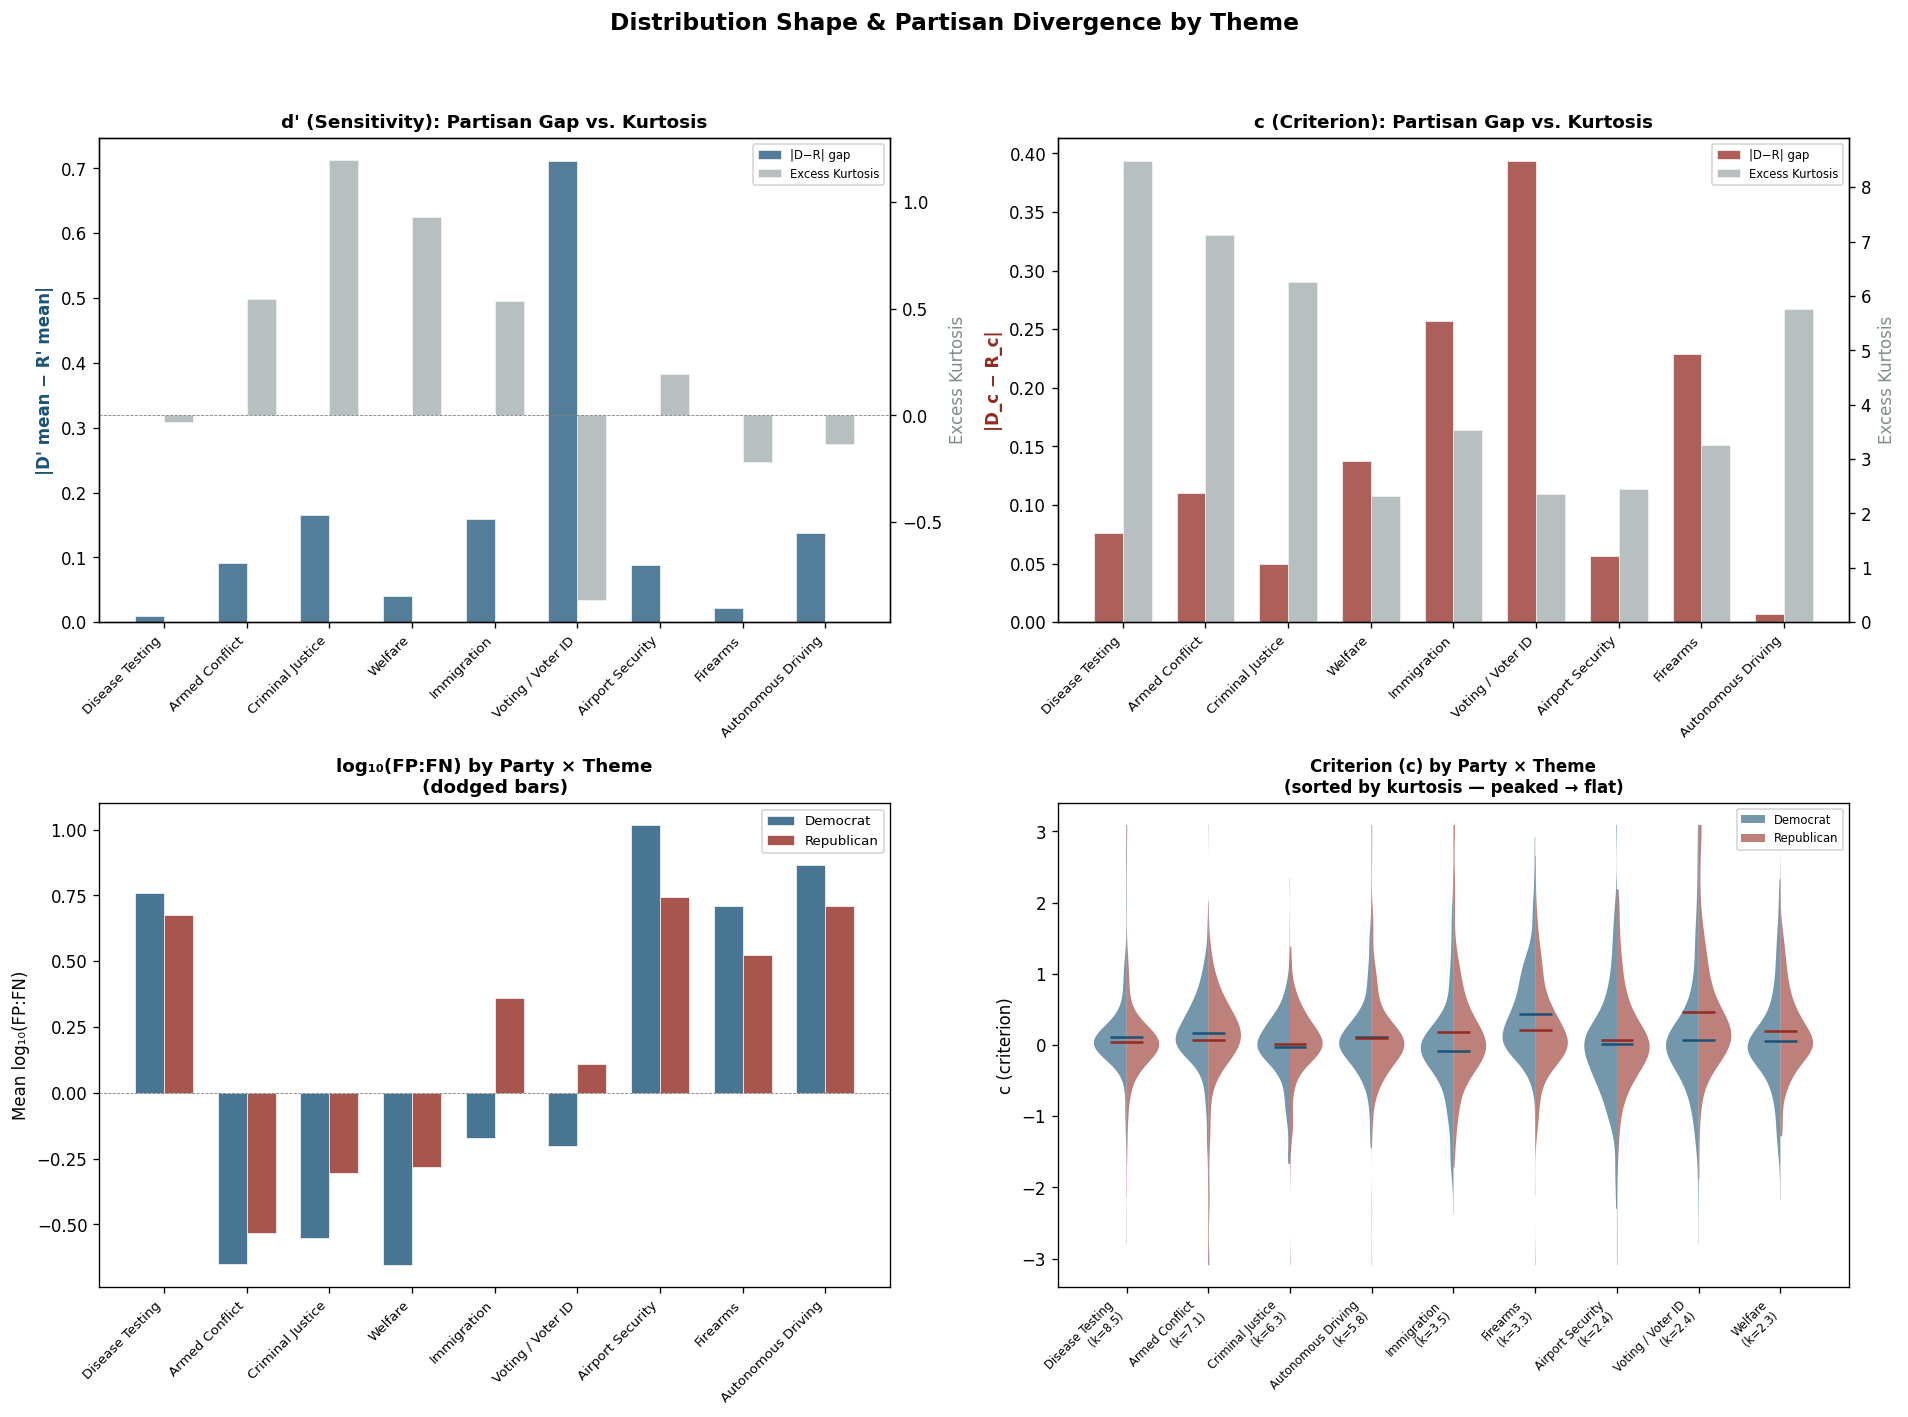


PARTISAN GAP & KURTOSIS RANKING BY THEME

  d':
  Theme                   |D−R| gap       Kurt         SD
  ───────────────────────────────────────────────────────
  Voting / Voter ID           0.711      -0.87      2.092
  Criminal Justice            0.165       1.20      1.748
  Immigration                 0.160       0.54      1.777
  Autonomous Driving          0.138      -0.13      1.800
  Armed Conflict              0.091       0.54      1.963
  Airport Security            0.088       0.19      1.970
  Welfare                     0.040       0.93      1.805
  Firearms                    0.021      -0.22      1.802
  Disease Testing             0.009      -0.03      1.847

  c:
  Theme                   |D−R| gap       Kurt         SD
  ───────────────────────────────────────────────────────
  Voting / Voter ID           0.393       2.37      0.866
  Immigration                 0.257       3.54      0.752
  Firearms                    0.229       3.26      0.684
  Welfare        

In [24]:
# --- 6b. Kurtosis & Partisan Divergence by Theme ---
# Shows which issues have the most/least partisan disagreement on SDT parameters,
# and which have tighter vs. flatter distributions.

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Distribution Shape & Partisan Divergence by Theme',
             fontsize=14, fontweight='bold', y=0.98)

# ── Helper: compute |D_mean - R_mean| and pooled kurtosis per theme ──
def partisan_gap(long_df, var, themes=THEMES):
    """Returns lists of theme labels, |D-R| gaps, and kurtosis."""
    labels, gaps, kurts = [], [], []
    for theme in themes:
        td = long_df[long_df['theme'] == theme][var].dropna()
        d_vals = long_df[(long_df['theme'] == theme) &
                         (long_df['party_binary'] == 'Democrat')][var].dropna()
        r_vals = long_df[(long_df['theme'] == theme) &
                         (long_df['party_binary'] == 'Republican')][var].dropna()
        if len(d_vals) < 3 or len(r_vals) < 3:
            continue
        labels.append(THEME_NAMES[theme])
        gaps.append(abs(d_vals.mean() - r_vals.mean()))
        kurts.append(kurtosis(td))
    return labels, gaps, kurts

width = 0.35

# ── Panel A: d' — |D - R| gap + kurtosis ──
ax = axes[0, 0]
labels, gaps, kurts = partisan_gap(long, 'd_prime')
x = np.arange(len(labels))
bars1 = ax.bar(x - width/2, gaps, width, color=PARTY_COLORS['Democrat'],
               alpha=0.75, edgecolor='white', linewidth=0.5, label='|D−R| gap')
ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, kurts, width, color='#7f8c8d',
                alpha=0.55, edgecolor='white', linewidth=0.5, label='Excess Kurtosis')
ax.set_ylabel("|D' mean − R' mean|", color=PARTY_COLORS['Democrat'], fontweight='bold')
ax2.set_ylabel('Excess Kurtosis', color='#7f8c8d')
ax.set_title("d' (Sensitivity): Partisan Gap vs. Kurtosis", fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.legend([bars1, bars2], ['|D−R| gap', 'Excess Kurtosis'],
          loc='upper right', fontsize=7)
ax2.axhline(0, color='gray', linewidth=0.5, linestyle='--')

# ── Panel B: c — |D - R| gap + kurtosis ──
ax = axes[0, 1]
labels, gaps, kurts = partisan_gap(long, 'c_sdt')
x = np.arange(len(labels))
bars1 = ax.bar(x - width/2, gaps, width, color=PARTY_COLORS['Republican'],
               alpha=0.75, edgecolor='white', linewidth=0.5, label='|D−R| gap')
ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, kurts, width, color='#7f8c8d',
                alpha=0.55, edgecolor='white', linewidth=0.5, label='Excess Kurtosis')
ax.set_ylabel('|D_c − R_c|', color=PARTY_COLORS['Republican'], fontweight='bold')
ax2.set_ylabel('Excess Kurtosis', color='#7f8c8d')
ax.set_title("c (Criterion): Partisan Gap vs. Kurtosis", fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.legend([bars1, bars2], ['|D−R| gap', 'Excess Kurtosis'],
          loc='upper right', fontsize=7)
ax2.axhline(0, color='gray', linewidth=0.5, linestyle='--')

# ── Panel C: log_ratio — dodged D vs R bars ──
ax = axes[1, 0]
ax.set_title("log₁₀(FP:FN) by Party × Theme\n(dodged bars)", fontweight='bold')

theme_labels_lr, d_means, r_means = [], [], []
for theme in THEMES:
    d_vals = long[(long['theme'] == theme) &
                  (long['party_binary'] == 'Democrat')]['log_ratio'].dropna()
    r_vals = long[(long['theme'] == theme) &
                  (long['party_binary'] == 'Republican')]['log_ratio'].dropna()
    if len(d_vals) < 3 or len(r_vals) < 3:
        continue
    theme_labels_lr.append(THEME_NAMES[theme])
    d_means.append(d_vals.mean())
    r_means.append(r_vals.mean())

x = np.arange(len(theme_labels_lr))
ax.bar(x - width/2, d_means, width, color=PARTY_COLORS['Democrat'],
       alpha=0.8, edgecolor='white', linewidth=0.5, label='Democrat')
ax.bar(x + width/2, r_means, width, color=PARTY_COLORS['Republican'],
       alpha=0.8, edgecolor='white', linewidth=0.5, label='Republican')
ax.set_xticks(x)
ax.set_xticklabels(theme_labels_lr, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean log₁₀(FP:FN)')
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.legend(fontsize=8)

# ── Panel D: Split violins of c by party × theme (sorted by kurtosis) ──
ax = axes[1, 1]
ax.set_title('Criterion (c) by Party × Theme\n(sorted by kurtosis — peaked → flat)',
             fontweight='bold', fontsize=10)

theme_kurt = []
for theme in THEMES:
    td = long[long['theme'] == theme]['c_sdt'].dropna()
    if len(td) >= 3:
        theme_kurt.append((theme, kurtosis(td)))
theme_kurt.sort(key=lambda x: x[1], reverse=True)

for i, (theme, k) in enumerate(theme_kurt):
    for party, side, color in [('Democrat', -1, PARTY_COLORS['Democrat']),
                                ('Republican', 1, PARTY_COLORS['Republican'])]:
        vals = long[(long['theme'] == theme) &
                    (long['party_binary'] == party)]['c_sdt'].dropna().values
        if len(vals) < 3:
            continue
        parts = ax.violinplot([vals], positions=[i], showmeans=True,
                              showmedians=False, showextrema=False, widths=0.8)
        # Clip each half: D on left, R on right
        for pc in parts['bodies']:
            m = np.mean(pc.get_paths()[0].vertices[:, 0])
            if side == -1:  # Democrat: keep left half
                pc.get_paths()[0].vertices[:, 0] = np.clip(
                    pc.get_paths()[0].vertices[:, 0], -np.inf, m)
            else:           # Republican: keep right half
                pc.get_paths()[0].vertices[:, 0] = np.clip(
                    pc.get_paths()[0].vertices[:, 0], m, np.inf)
            pc.set_facecolor(color)
            pc.set_alpha(0.6)
        parts['cmeans'].set_color(color)
        parts['cmeans'].set_linewidth(1.5)

# Labels
theme_labels_v = [f"{THEME_NAMES[t]}\n(k={k:.1f})" for t, k in theme_kurt]
ax.set_xticks(range(len(theme_labels_v)))
ax.set_xticklabels(theme_labels_v, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('c (criterion)')
# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=PARTY_COLORS['Democrat'], alpha=0.6, label='Democrat'),
                   Patch(facecolor=PARTY_COLORS['Republican'], alpha=0.6, label='Republican')],
          loc='upper right', fontsize=7)

plt.tight_layout(rect=[0, 0, 1, 0.95])
try:
    plt.savefig(SAVE_DIR + '6b_kurtosis_variance_by_theme.png', dpi=150, bbox_inches='tight')
except (FileNotFoundError, OSError):
    pass
plt.show()

# ── Summary table ──
print("\n" + "=" * 90)
print("PARTISAN GAP & KURTOSIS RANKING BY THEME")
print("=" * 90)
for var, label in [('d_prime', "d'"), ('c_sdt', 'c'), ('log_ratio', 'log_ratio')]:
    print(f"\n  {label}:")
    print(f"  {'Theme':<22} {'|D−R| gap':>10} {'Kurt':>10} {'SD':>10}")
    print(f"  {'─'*55}")
    ranked = []
    for theme in THEMES:
        td = long[long['theme'] == theme][var].dropna()
        d_vals = long[(long['theme'] == theme) &
                      (long['party_binary'] == 'Democrat')][var].dropna()
        r_vals = long[(long['theme'] == theme) &
                      (long['party_binary'] == 'Republican')][var].dropna()
        if len(d_vals) >= 3 and len(r_vals) >= 3:
            ranked.append((THEME_NAMES[theme],
                           abs(d_vals.mean() - r_vals.mean()),
                           kurtosis(td), td.std()))
    ranked.sort(key=lambda x: x[1], reverse=True)
    for name, gap, k, sd in ranked:
        print(f"  {name:<22} {gap:>10.3f} {k:>10.2f} {sd:>10.3f}")

## 7. Boxplots: d', c, log_ratio, Preference by Party × Theme

These are the key descriptive figures requested. They show the full
distribution by party for each theme, making variance differences,
outliers, and skew visible.

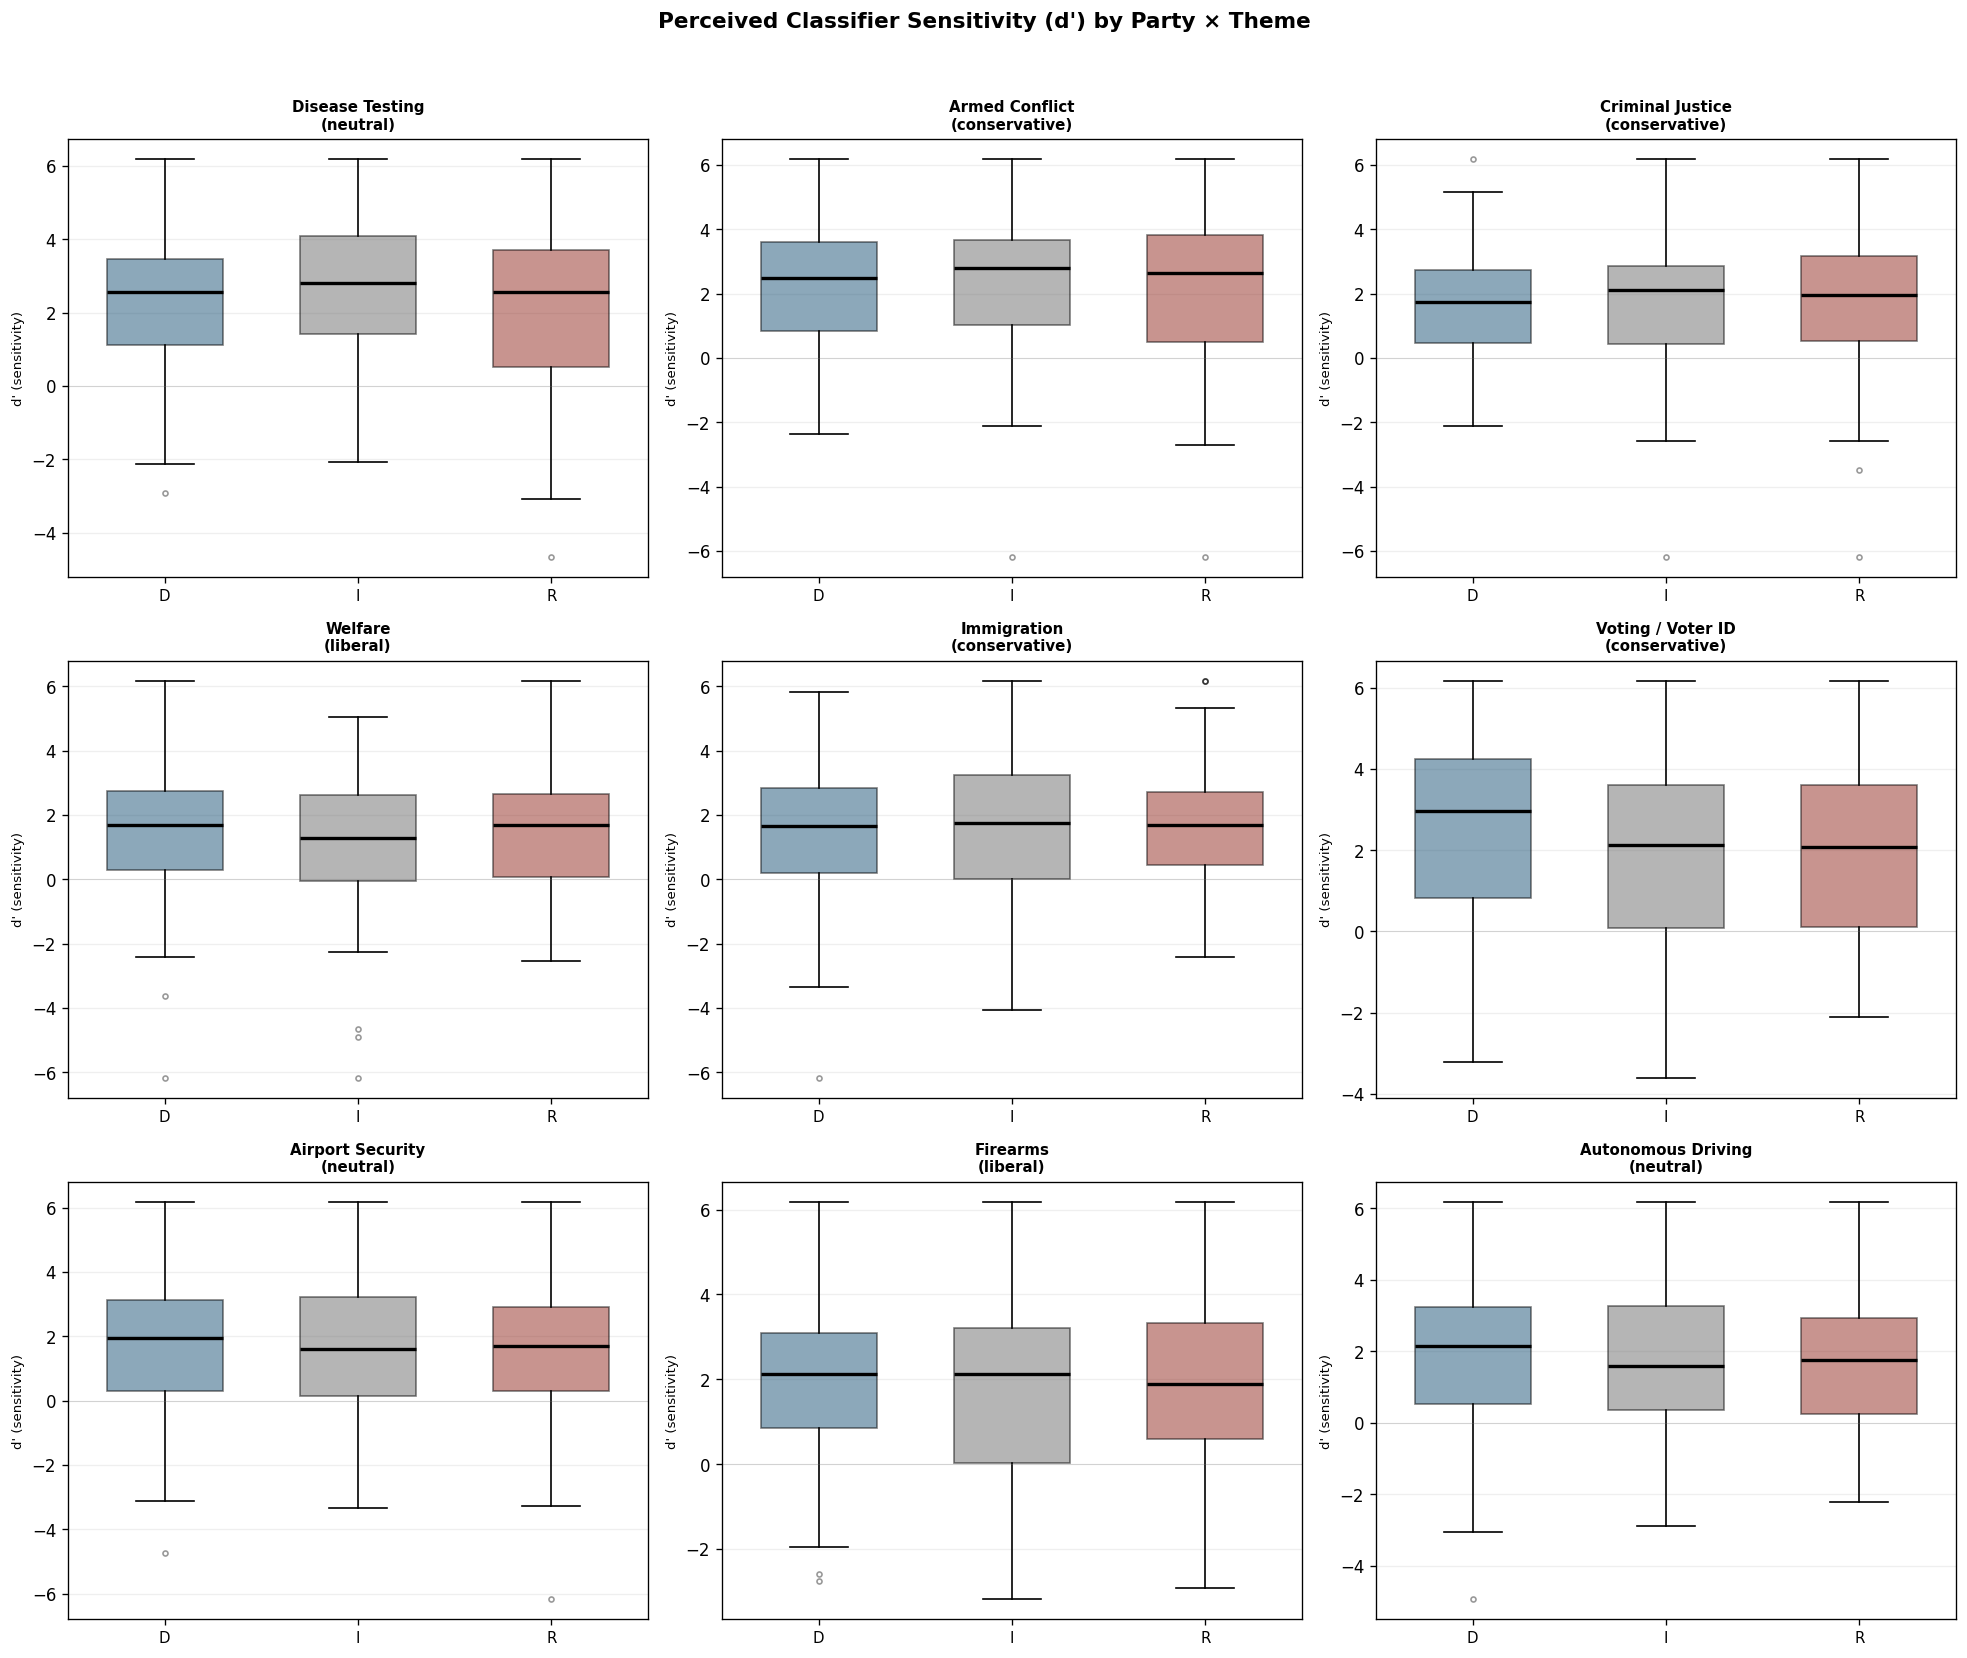

In [12]:
def boxplot_by_party_theme(long_df, var, ylabel, title, themes=None):
    """
    Create 3×3 boxplots showing distribution of `var` by party for each theme.
    Uses party_3 (Democrat / Independent / Republican).
    """
    if themes is None:
        themes = THEMES

    n_themes = len(themes)
    ncols = min(3, n_themes)
    nrows = int(np.ceil(n_themes / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.5 * nrows))
    if n_themes == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    parties = ['Democrat', 'Independent', 'Republican']

    for i, theme in enumerate(themes):
        ax = axes[i]
        td = long_df[long_df['theme'] == theme].dropna(subset=[var])

        # Build data for boxplot
        box_data = []
        box_positions = []
        box_colors = []
        for j, party in enumerate(parties):
            pdata = td[td['party_binary'] == party][var]
            if len(pdata) > 0:
                box_data.append(pdata.values)
                box_positions.append(j)
                box_colors.append(PARTY_COLORS[party])

        if box_data:
            bp = ax.boxplot(box_data, positions=box_positions, widths=0.6,
                           patch_artist=True, showfliers=True,
                           flierprops={'markersize': 3, 'alpha': 0.4})
            for patch, color in zip(bp['boxes'], box_colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.5)
            for median in bp['medians']:
                median.set_color('black')
                median.set_linewidth(2)

        ax.set_xticks(range(len(parties)))
        ax.set_xticklabels(['D', 'I', 'R'], fontsize=9)
        ax.set_title(f"{THEME_NAMES[theme]}\n({THEME_VALENCE[theme]})",
                     fontsize=9, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=8)
        ax.grid(axis='y', alpha=0.2)
        ax.axhline(0, color='gray', linewidth=0.5, alpha=0.3)

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# d'
boxplot_by_party_theme(long, 'd_prime', "d' (sensitivity)",
    "Perceived Classifier Sensitivity (d') by Party × Theme")

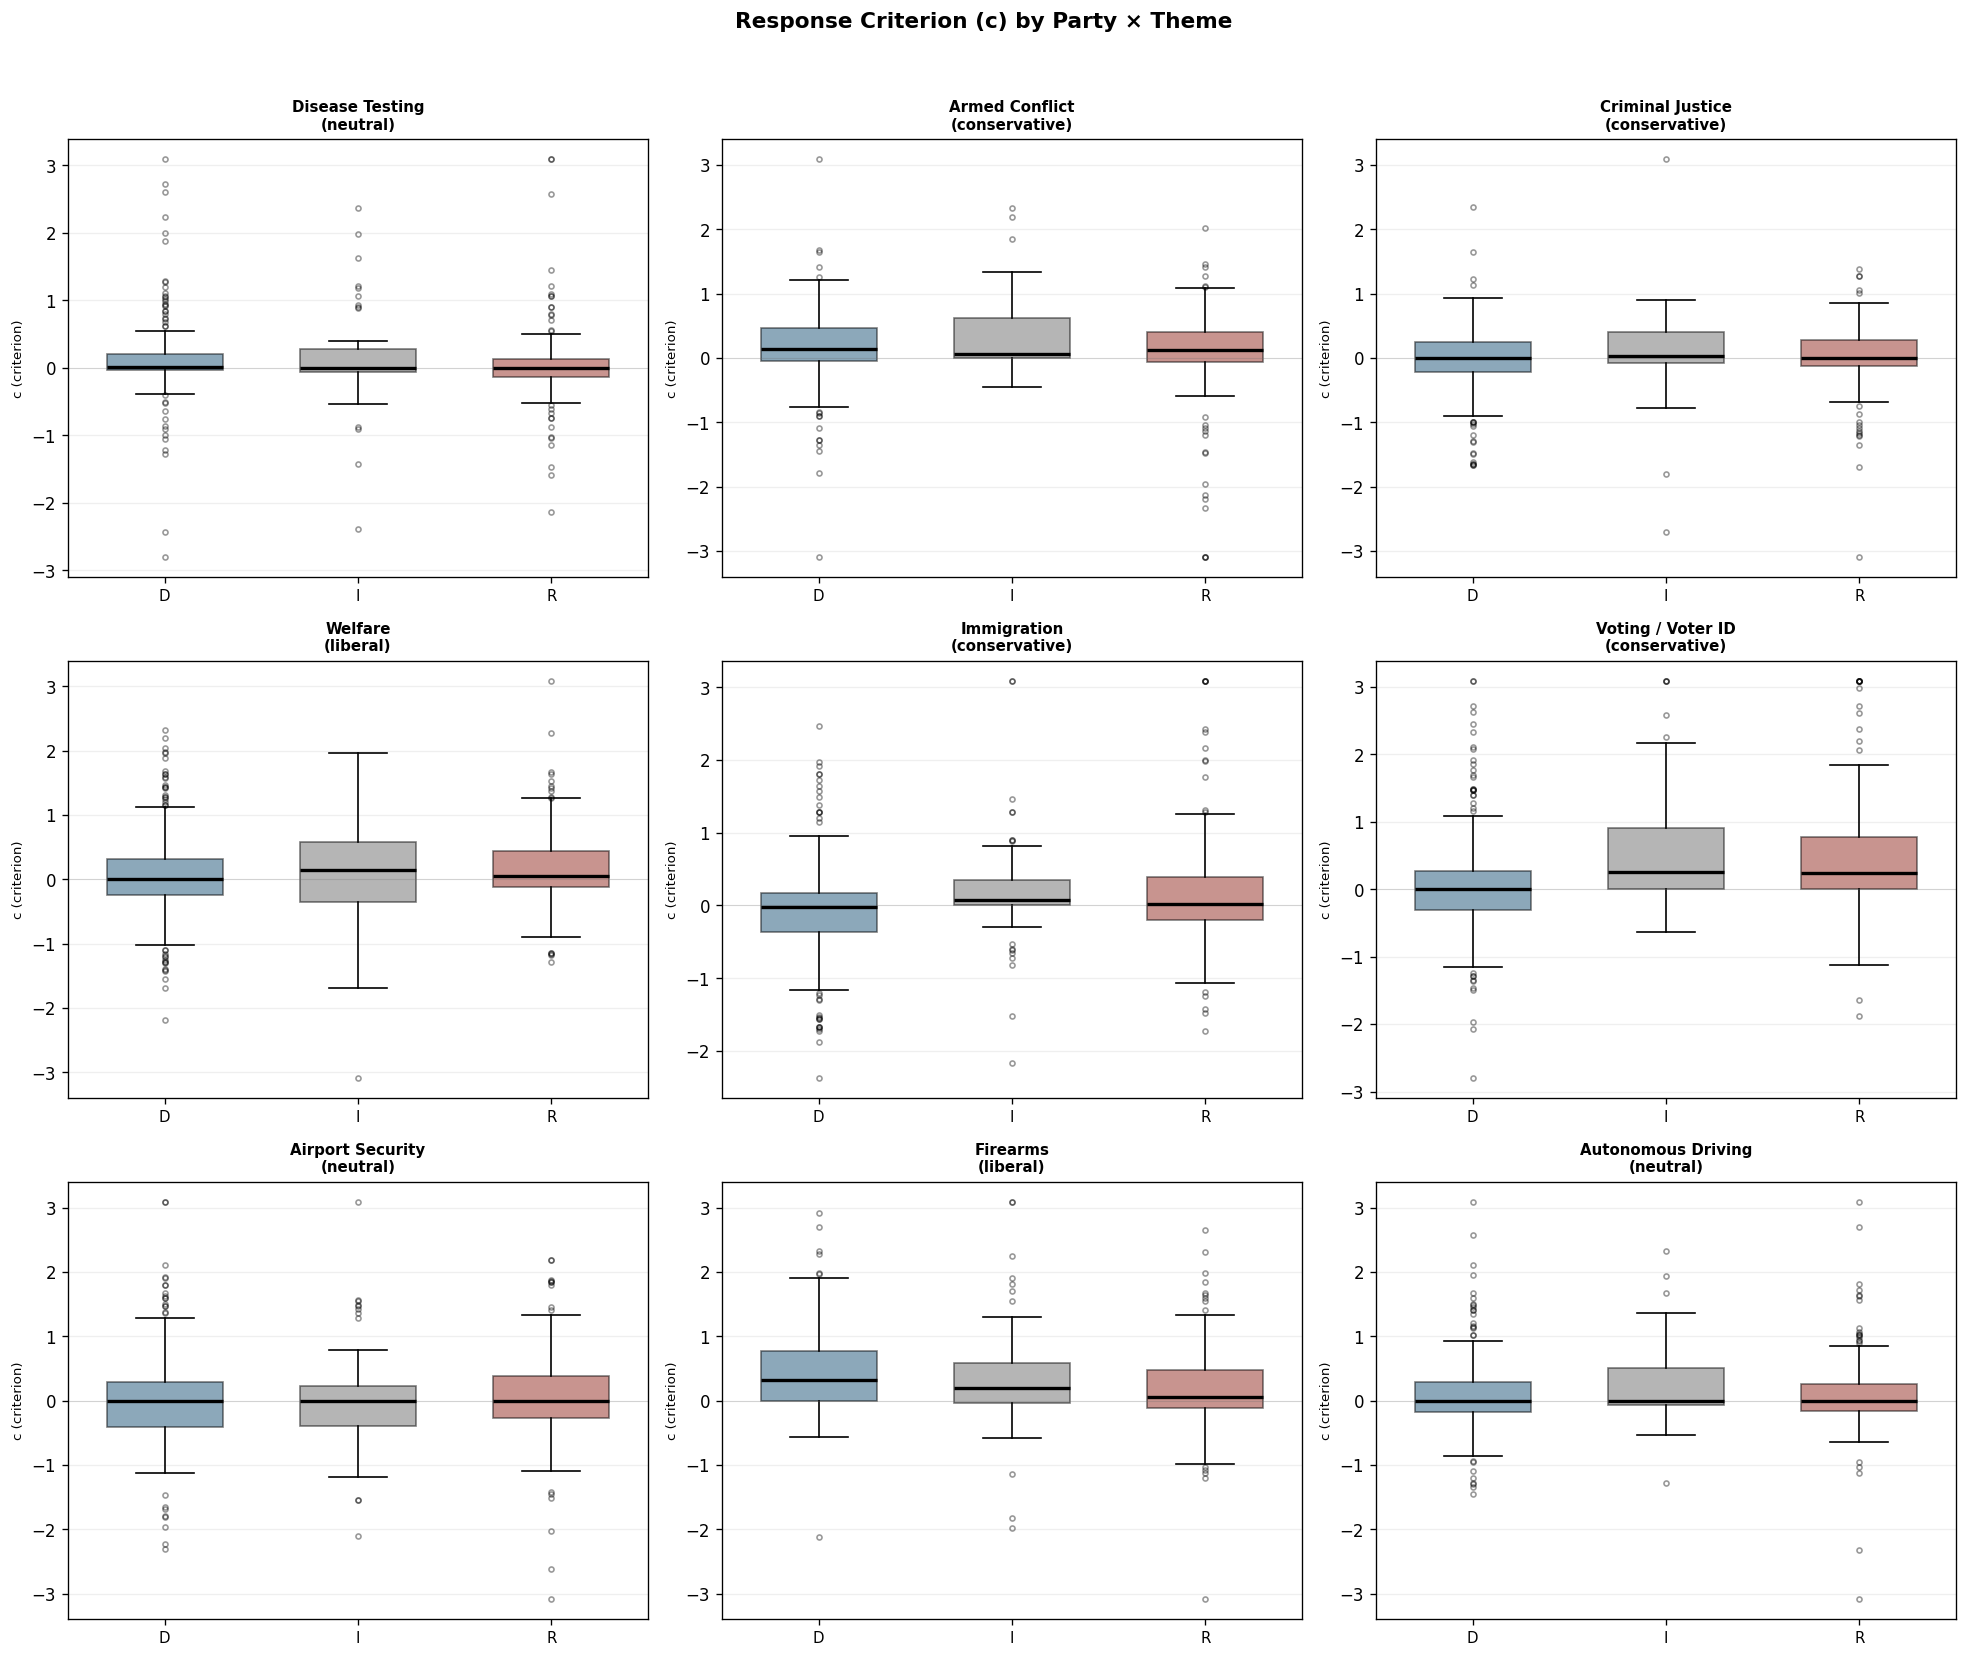

In [13]:
# c (criterion)
boxplot_by_party_theme(long, 'c_sdt', 'c (criterion)',
    "Response Criterion (c) by Party × Theme")

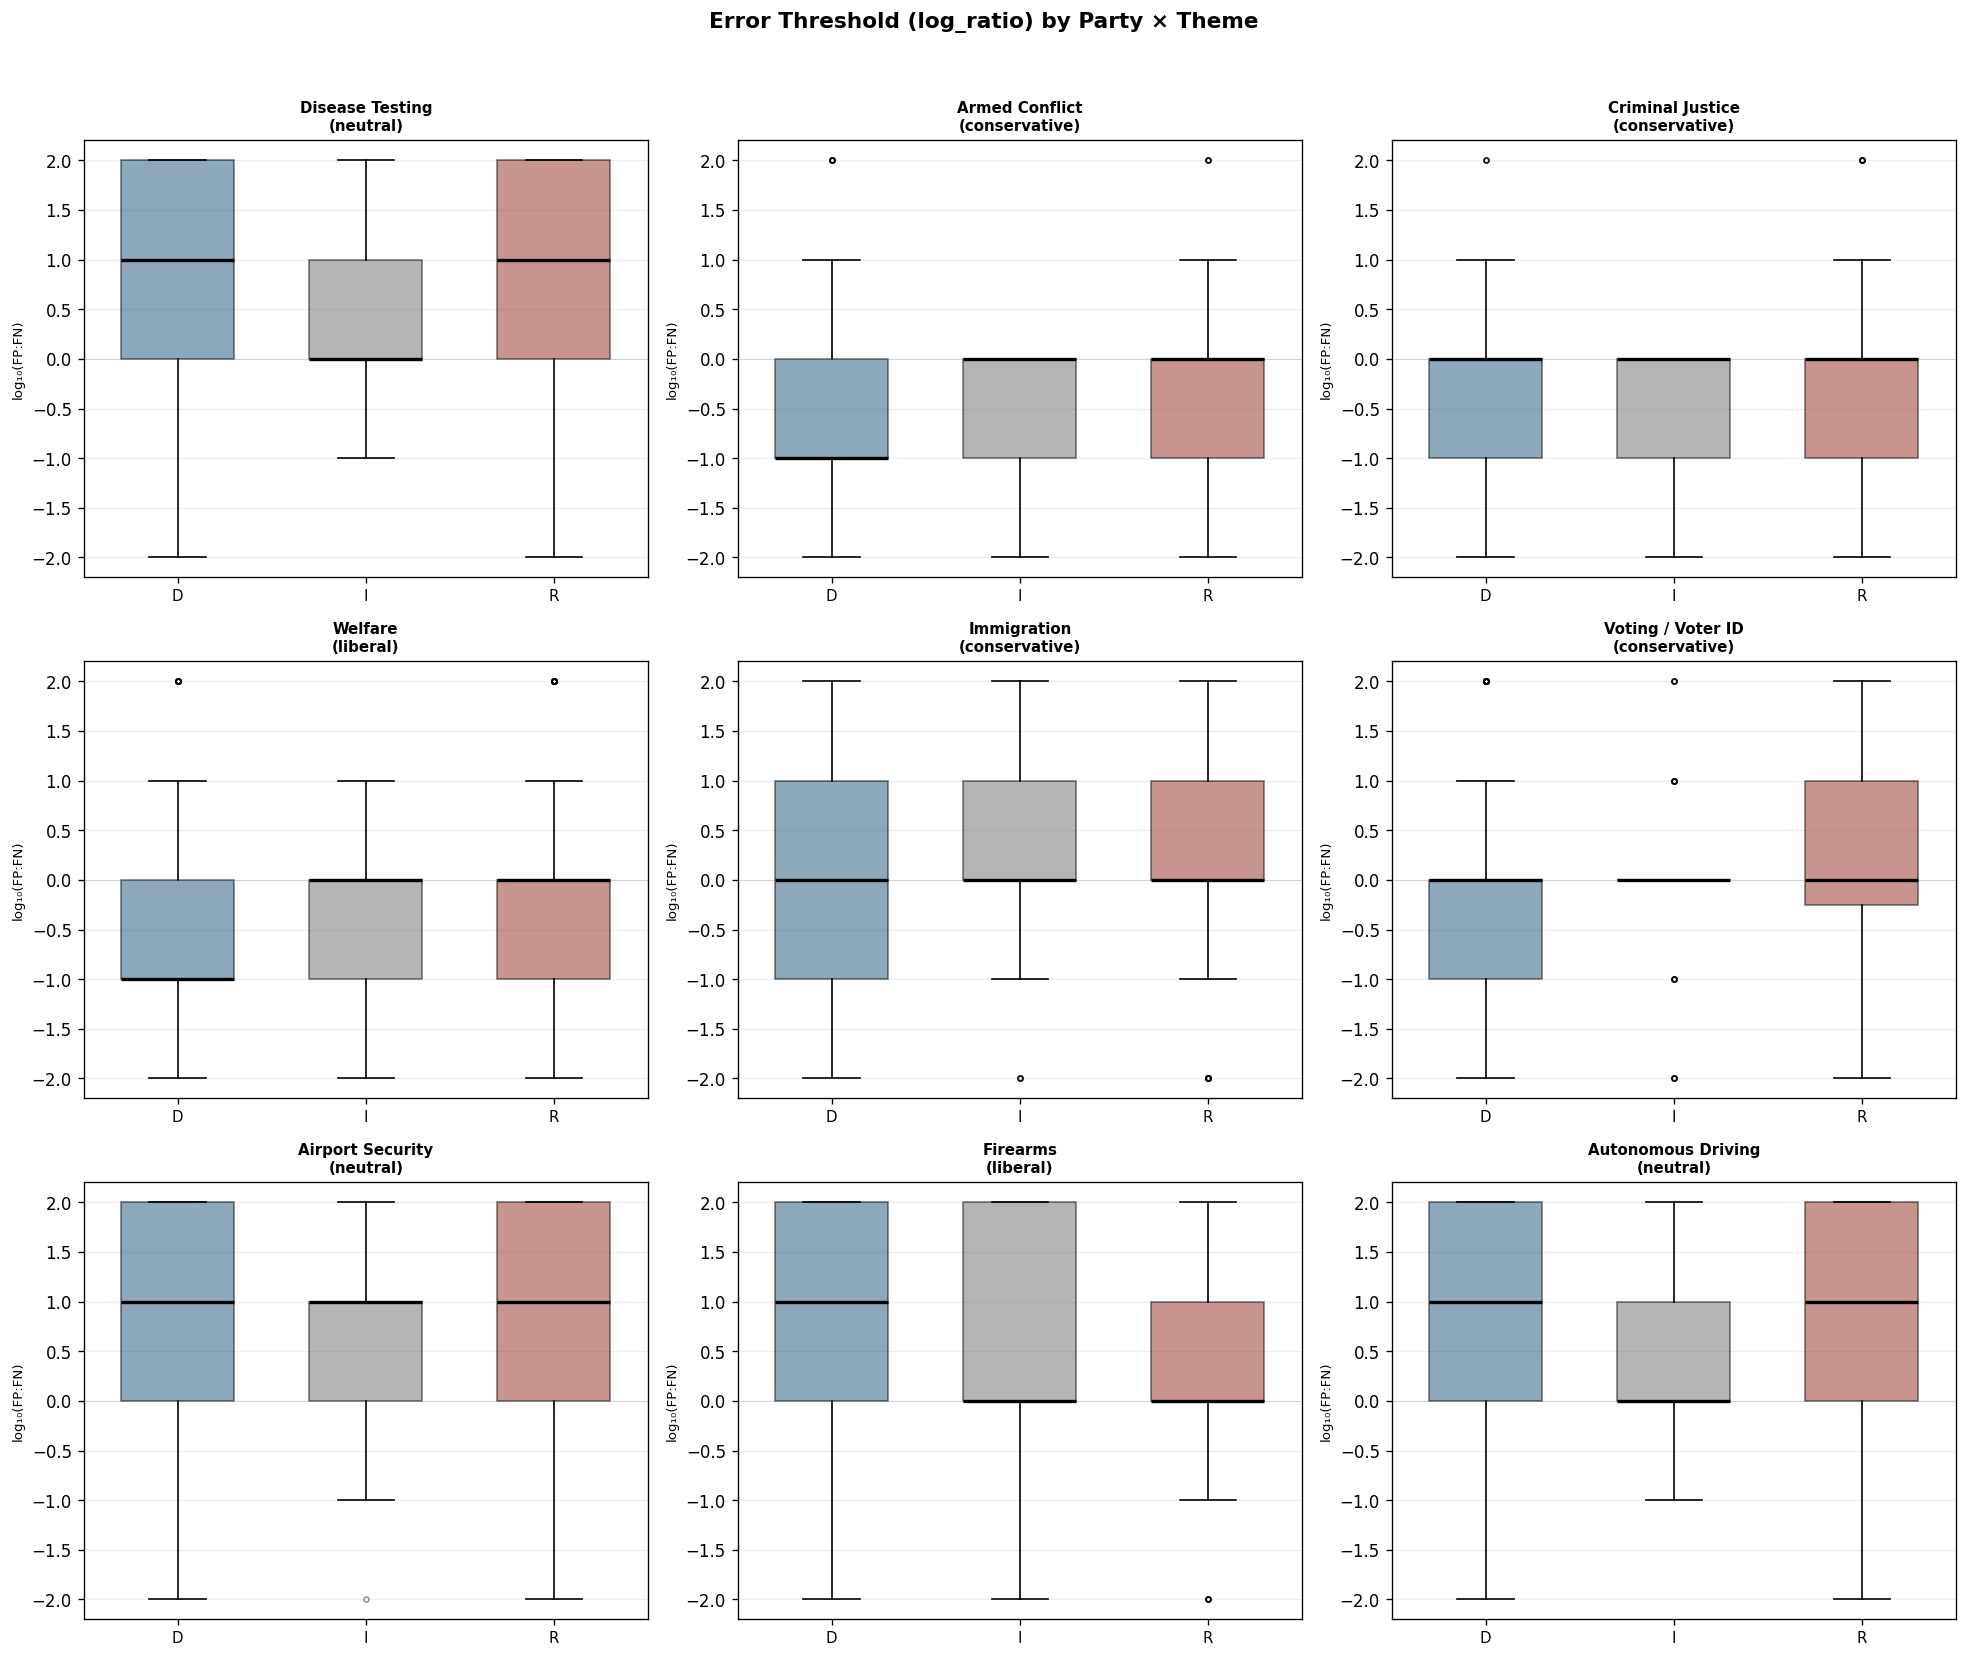

In [14]:
# log_ratio
boxplot_by_party_theme(long, 'log_ratio', 'log₁₀(FP:FN)',
    "Error Threshold (log_ratio) by Party × Theme")

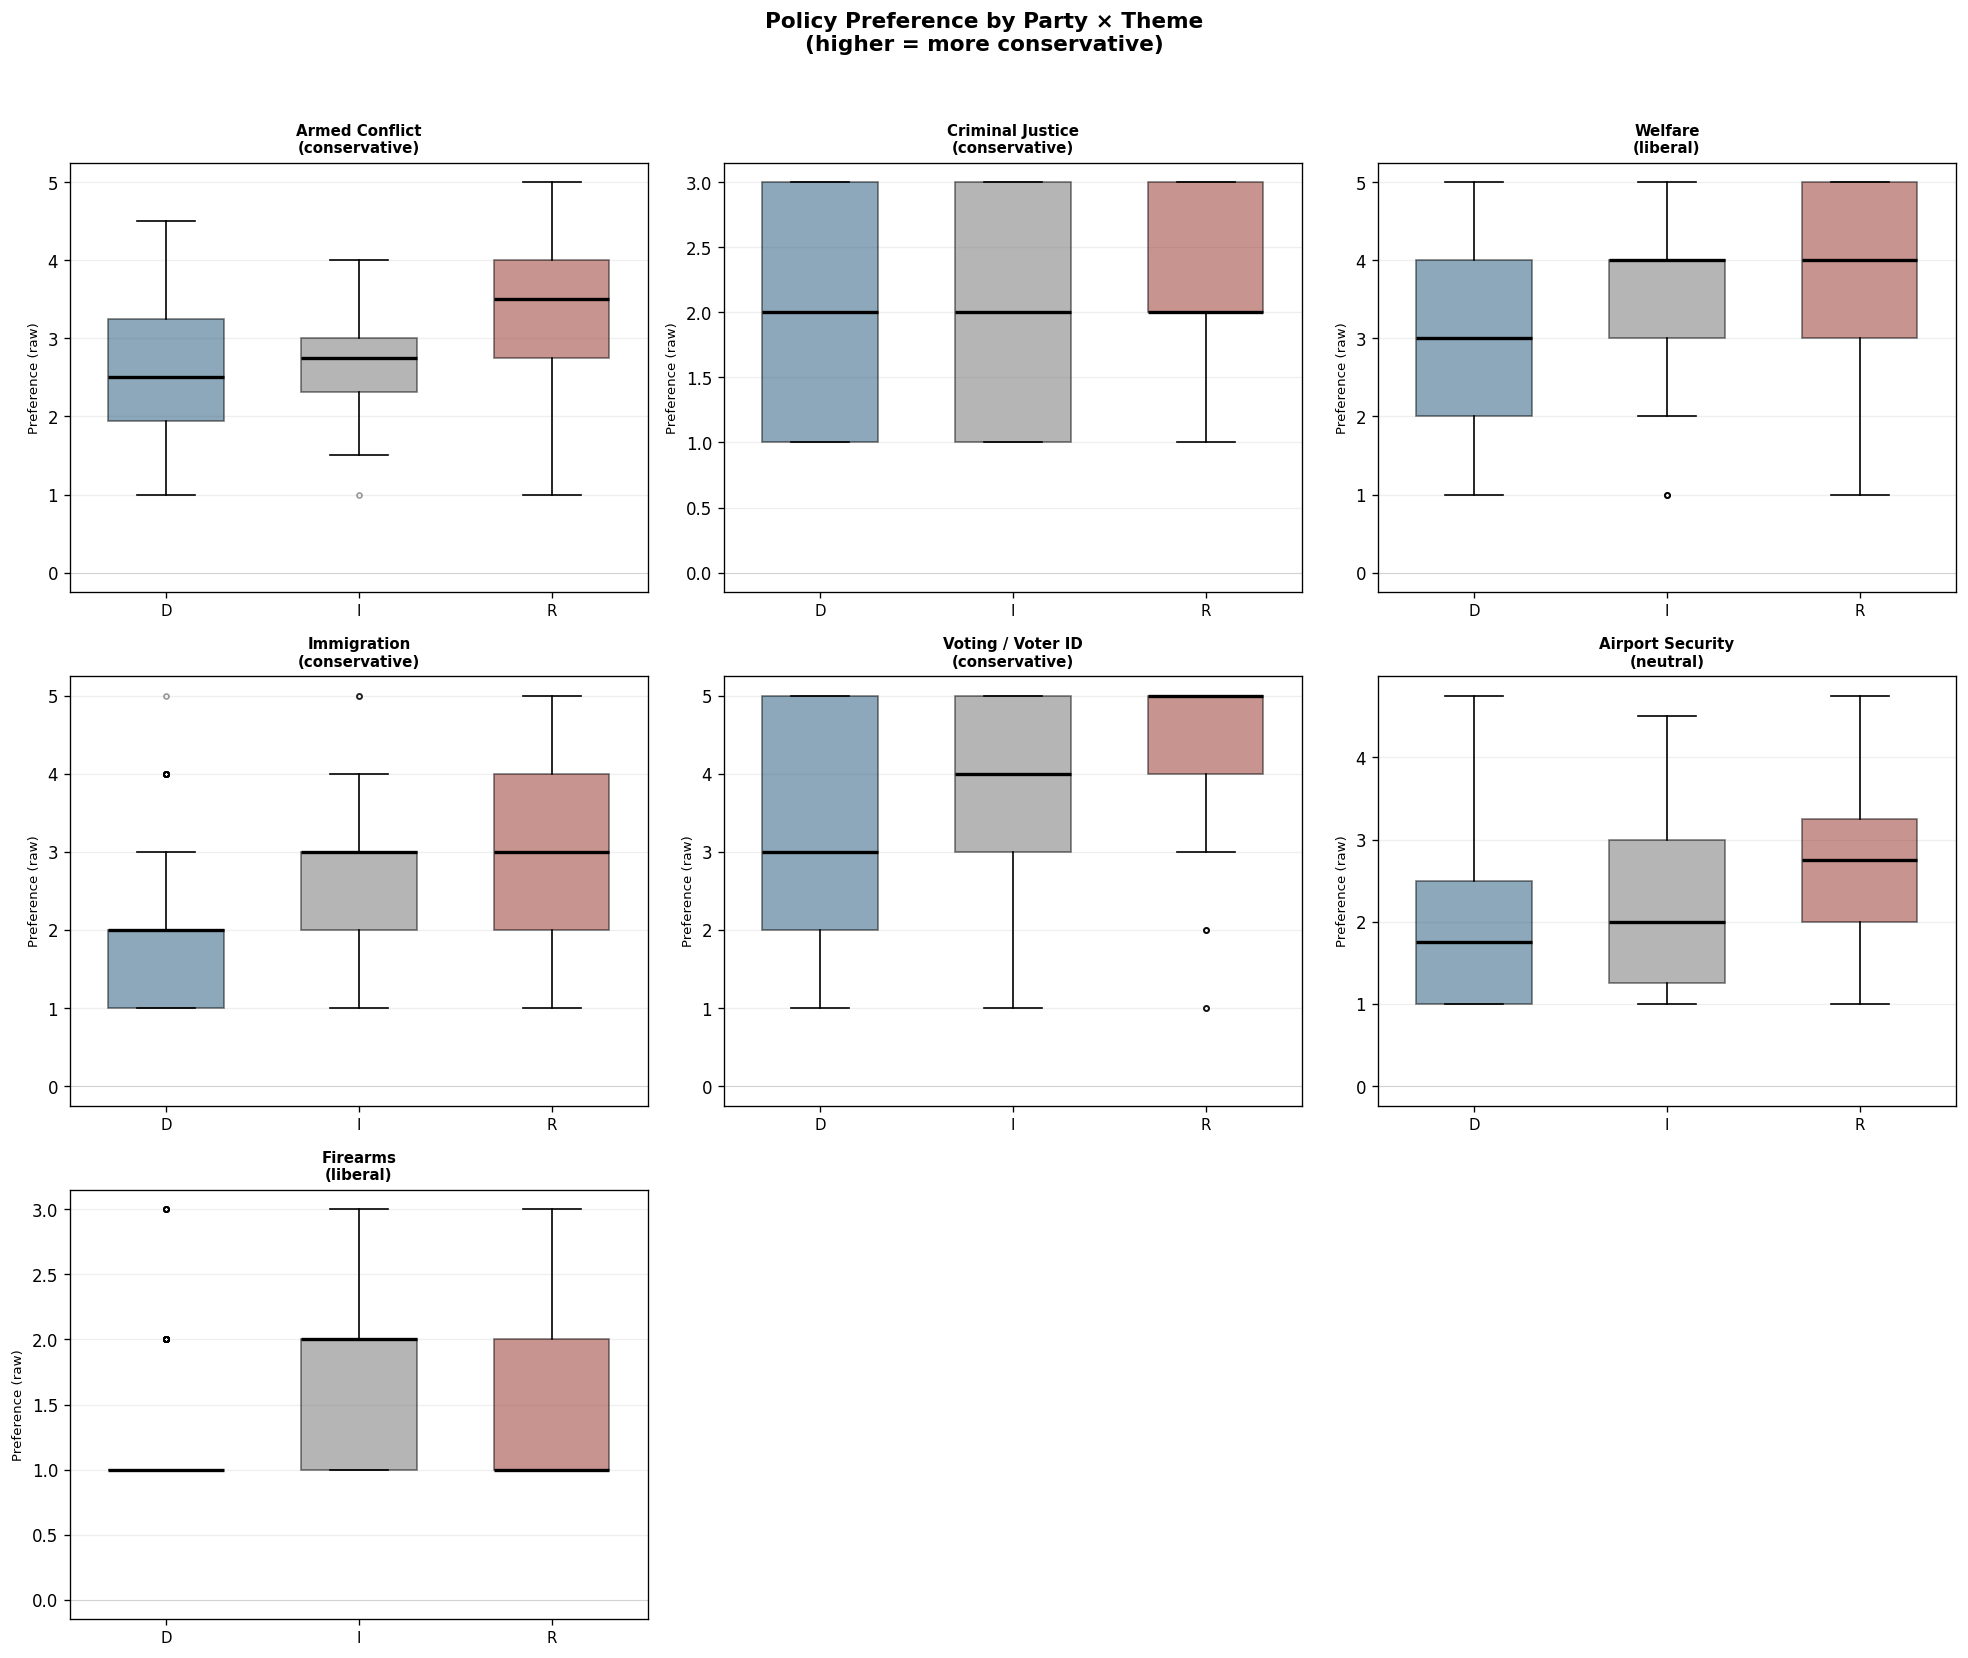

In [15]:
# Preference (only themes with matched preference variable)
pref_themes = list(THEME_PREF_MAP.keys())
boxplot_by_party_theme(long, 'preference', 'Preference (raw)',
    "Policy Preference by Party × Theme\n(higher = more conservative)",
    themes=pref_themes)

## 8. Logical Inconsistency in Base-Rate Calculations

Each participant provides 3 of 4 base-rate estimates (FP, FN, TP, TN out of 1,000).
Complementary pairs (e.g., FP + TN, TP + FN) should sum to 1,000.
`consistency_deviation` = |pair_sum − 1000| when both members of a pair are answered.

Large deviations indicate confusion about the probability framing or inattention.

BASE-RATE LOGICAL INCONSISTENCY (consistency_deviation)


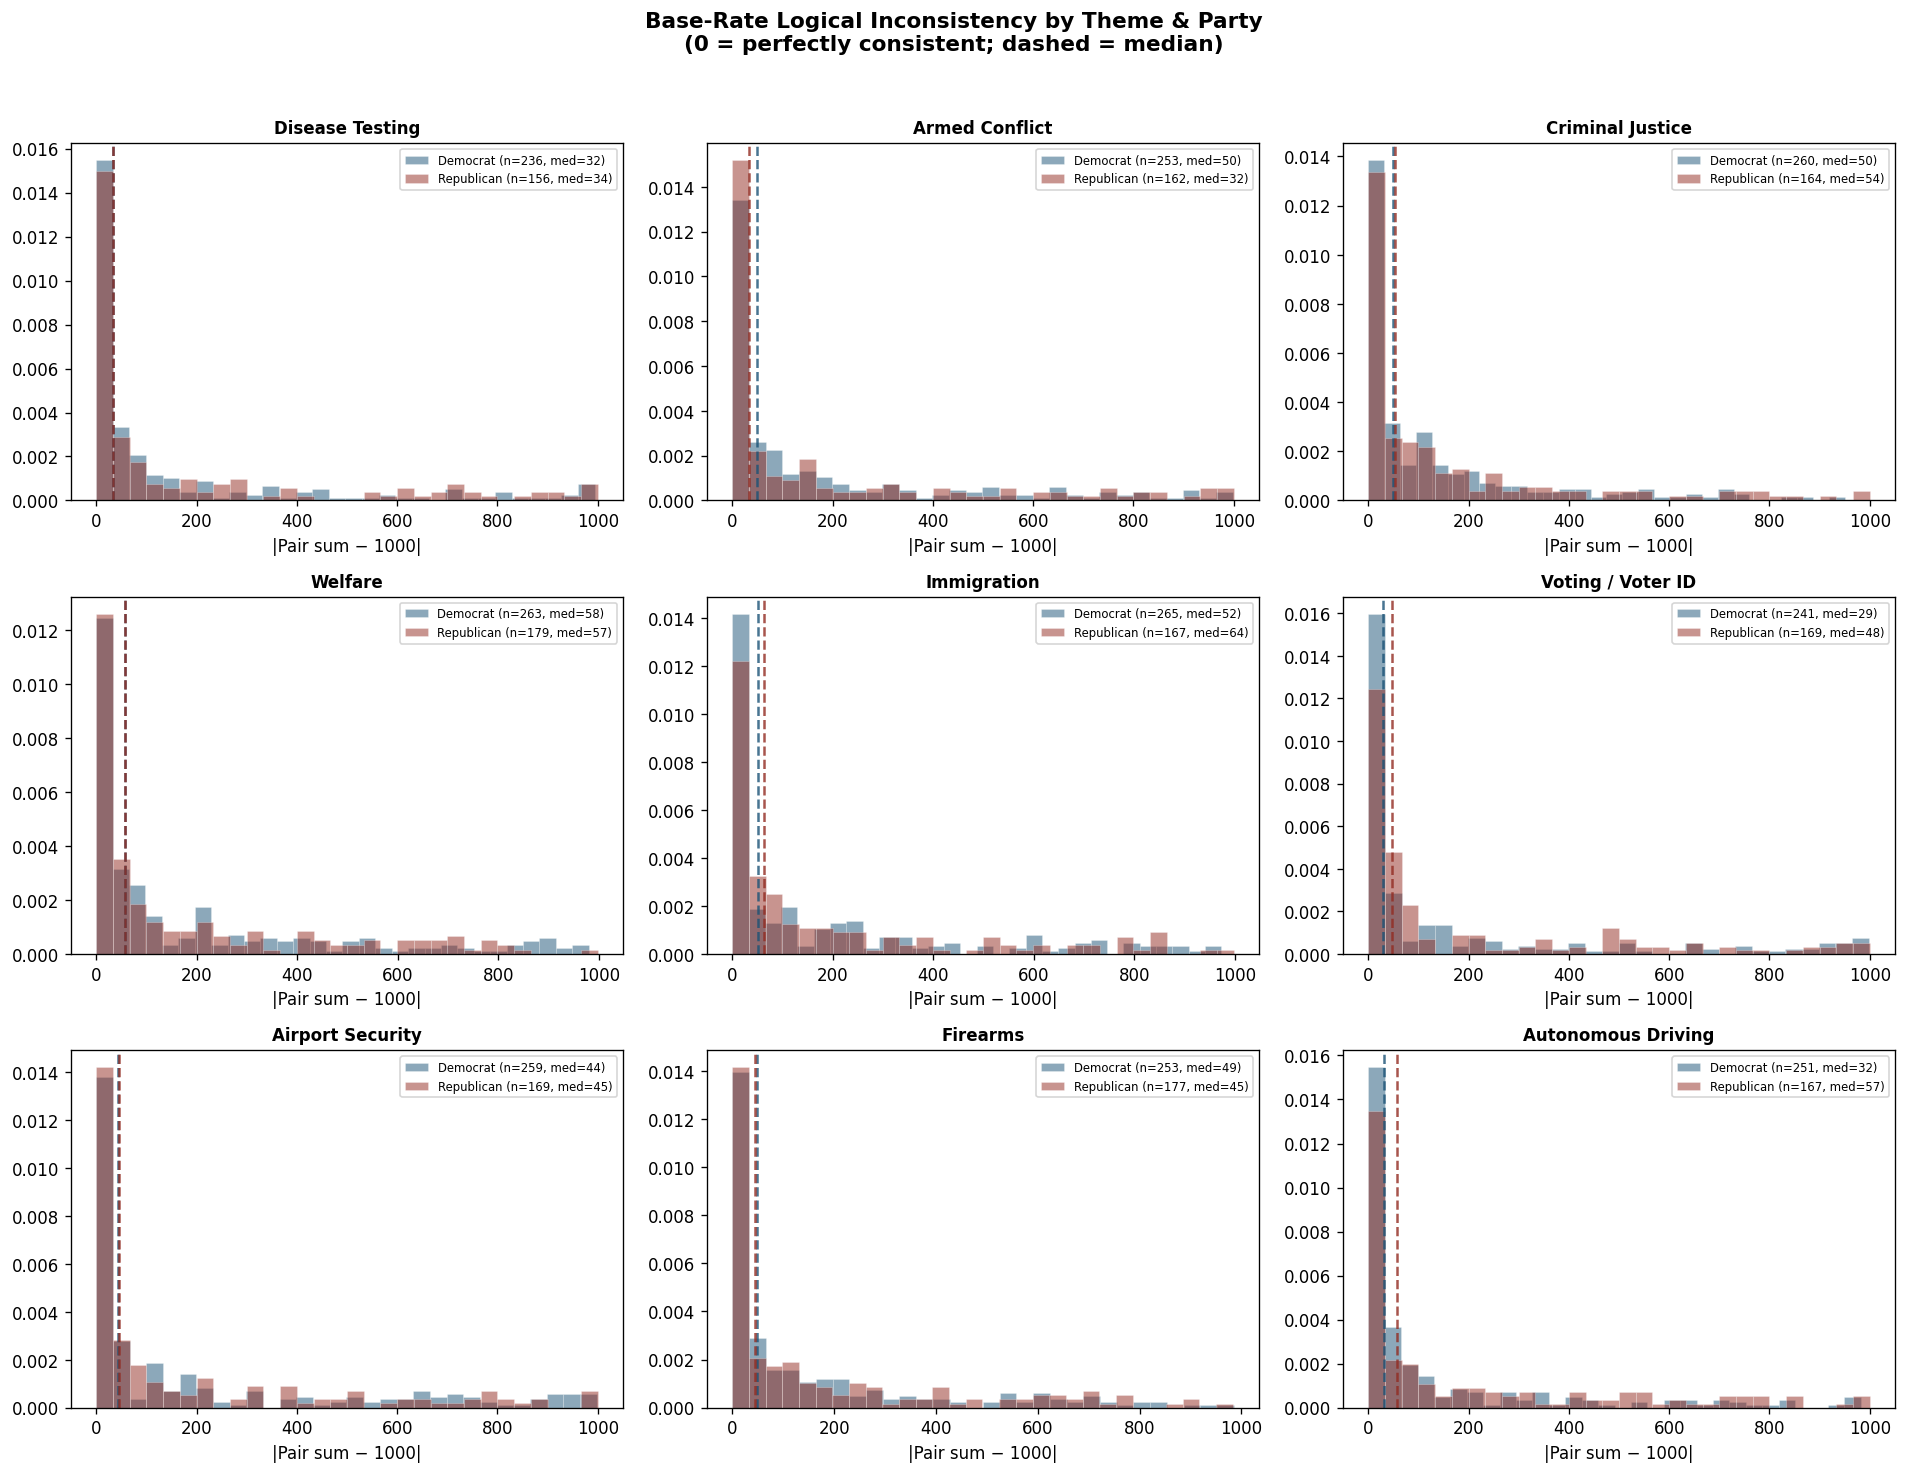

In [16]:
print("=" * 70)
print("BASE-RATE LOGICAL INCONSISTENCY (consistency_deviation)")
print("=" * 70)

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, theme in enumerate(THEMES):
    ax = axes[i]
    td = long[long['theme'] == theme].dropna(subset=['consistency_deviation'])

    for party in ['Democrat', 'Republican']:
        pdata = td[td['party_binary'] == party]['consistency_deviation']
        if len(pdata) > 0:
            ax.hist(pdata, bins=30, alpha=0.5, color=PARTY_COLORS[party],
                    label=f'{party} (n={len(pdata)}, med={pdata.median():.0f})',
                    density=True, edgecolor='white', linewidth=0.3)
            ax.axvline(pdata.median(), color=PARTY_COLORS[party],
                       linestyle='--', linewidth=1.5, alpha=0.8)

    ax.set_title(THEME_NAMES[theme], fontweight='bold', fontsize=10)
    ax.set_xlabel('|Pair sum − 1000|')
    ax.legend(fontsize=7)

fig.suptitle('Base-Rate Logical Inconsistency by Theme & Party\n'
             '(0 = perfectly consistent; dashed = median)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# Summary: inconsistency by party (aggregated to participant level first)
print("\n--- Participant-Level Mean Inconsistency by Party ---")
part_consistency = long.groupby(['respondent_id', 'party_binary'])['consistency_deviation'].mean().reset_index()
for party in ['Democrat', 'Independent', 'Republican']:
    pdata = part_consistency[part_consistency['party_binary'] == party]['consistency_deviation']
    if len(pdata) > 0:
        print(f"  {party:<14} n={len(pdata):>4}  mean={pdata.mean():.1f}  "
              f"median={pdata.median():.1f}  SD={pdata.std():.1f}")

# Test
dem = part_consistency[part_consistency['party_binary'] == 'Democrat']['consistency_deviation']
rep = part_consistency[part_consistency['party_binary'] == 'Republican']['consistency_deviation']
if len(dem) > 3 and len(rep) > 3:
    t, p = ttest_ind(dem, rep)
    u, p_u = mannwhitneyu(dem, rep, alternative='two-sided')
    print(f"\n  D vs R t-test: t={t:.3f}, p={p:.4f}")
    print(f"  D vs R Mann-Whitney: U={u:.0f}, p={p_u:.4f}")


--- Participant-Level Mean Inconsistency by Party ---
  Democrat       n= 343  mean=167.7  median=129.4  SD=165.4
  Independent    n=  79  mean=194.5  median=142.9  SD=196.1
  Republican     n= 227  mean=184.5  median=146.6  SD=189.6

  D vs R t-test: t=nan, p=nan
  D vs R Mann-Whitney: U=nan, p=nan


## 9. Below-Diagonal Operating Points

Participants whose (FPR, TPR) falls *below* the x=y diagonal believe the
policy classifier is performing worse than chance — their FPR exceeds
their TPR. This could indicate confusion, inattention, or genuinely
inverted beliefs.

In [18]:
print("=" * 70)
print("BELOW-DIAGONAL OPERATING POINTS")
print("=" * 70)

# Count per theme
print("\n--- Proportion below diagonal by theme ---")
for theme in THEMES:
    td = long[(long['theme'] == theme)].dropna(subset=['fpr', 'tpr'])
    n_below = td['below_diagonal'].sum()
    print(f"  {THEME_NAMES[theme]:<20}  {n_below:>4} / {len(td):>4}  "
          f"({100 * n_below / len(td):.1f}%)")

# Per-participant: how many themes are below diagonal?
part_below = long.dropna(subset=['fpr', 'tpr']).groupby('respondent_id').agg(
    n_themes=('theme', 'count'),
    n_below=('below_diagonal', 'sum'),
).reset_index()
part_below['prop_below'] = part_below['n_below'] / part_below['n_themes']

print(f"\n--- Participant-level below-diagonal count ---")
print(part_below['n_below'].value_counts().sort_index().to_string())
print(f"\n  Mean themes below diagonal: {part_below['n_below'].mean():.2f}")
print(f"  Participants with 0 below: {(part_below['n_below'] == 0).sum()}")
print(f"  Participants with >50% below: {(part_below['prop_below'] > 0.5).sum()}")

BELOW-DIAGONAL OPERATING POINTS

--- Proportion below diagonal by theme ---
  Disease Testing         54 /  455  (11.9%)
  Armed Conflict          68 /  476  (14.3%)
  Criminal Justice        69 /  484  (14.3%)
  Welfare                100 /  509  (19.6%)
  Immigration             82 /  488  (16.8%)
  Voting / Voter ID       73 /  477  (15.3%)
  Airport Security        88 /  496  (17.7%)
  Firearms                68 /  491  (13.8%)
  Autonomous Driving      68 /  487  (14.0%)

--- Participant-level below-diagonal count ---
n_below
0    326
1    138
2     80
3     52
4     27
5     12
6      8

  Mean themes below diagonal: 1.04
  Participants with 0 below: 326
  Participants with >50% below: 50



--- Below-Diagonal Cross-Theme Correlations ---
  Mean pairwise r = 0.200
  (If positive, below-diagonal is a stable participant trait)


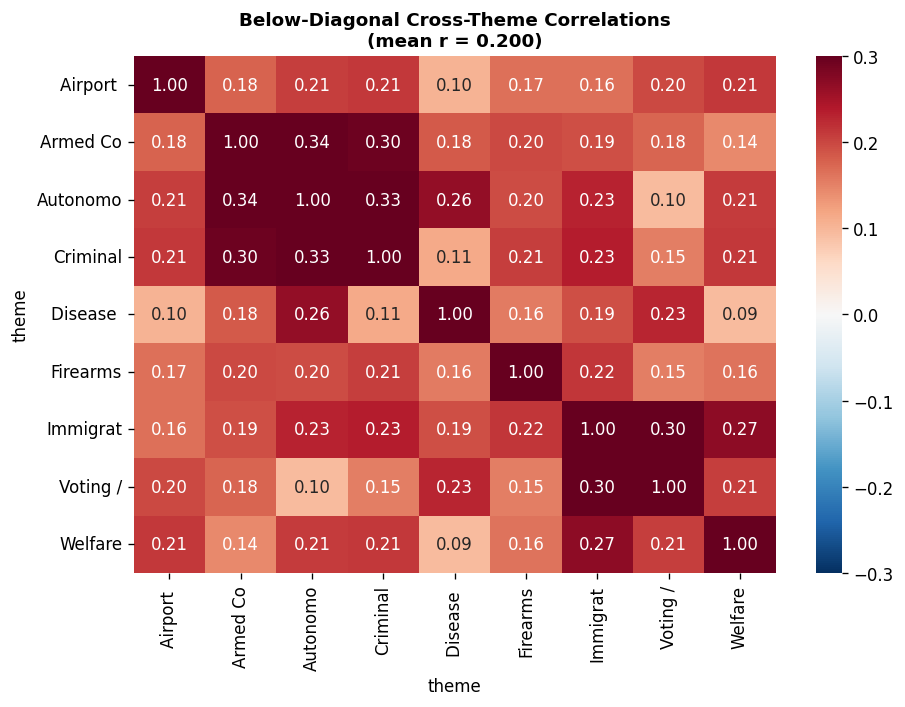

In [19]:
# Cross-theme consistency: does being below on one predict being below on others?
# Compute participant × theme below-diagonal pivot
below_wide = long.dropna(subset=['fpr', 'tpr']).pivot_table(
    index='respondent_id', columns='theme', values='below_diagonal', aggfunc='first'
)
# Pairwise correlation of below-diagonal flags across themes
below_corr = below_wide.corr()
print("\n--- Below-Diagonal Cross-Theme Correlations ---")
# Average off-diagonal correlation
mask_tri = np.triu(np.ones(below_corr.shape, dtype=bool), k=1)
avg_corr = below_corr.values[mask_tri].mean()
print(f"  Mean pairwise r = {avg_corr:.3f}")
print(f"  (If positive, below-diagonal is a stable participant trait)")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(below_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, vmin=-0.3, vmax=0.3,
            xticklabels=[THEME_NAMES.get(t, t)[:8] for t in below_corr.columns],
            yticklabels=[THEME_NAMES.get(t, t)[:8] for t in below_corr.index])
ax.set_title(f'Below-Diagonal Cross-Theme Correlations\n(mean r = {avg_corr:.3f})',
             fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# Validate existing exclusions: do excluded participants have more below-diagonal points?
att_ids = set(df[get_mask(df)]['ResponseId'])
all_long = build_long(df, use_attentive=False)
all_long['is_attentive'] = all_long['respondent_id'].isin(att_ids).astype(int)

bd_by_status = all_long.dropna(subset=['fpr', 'tpr']).groupby(
    ['respondent_id', 'is_attentive'])['below_diagonal'].mean().reset_index()

att_bd = bd_by_status[bd_by_status['is_attentive'] == 1]['below_diagonal']
exc_bd = bd_by_status[bd_by_status['is_attentive'] == 0]['below_diagonal']

print("\n--- Below-Diagonal Rate: Attentive vs Excluded ---")
print(f"  Attentive (n={len(att_bd)}): mean={att_bd.mean():.3f}, median={att_bd.median():.3f}")
print(f"  Excluded  (n={len(exc_bd)}): mean={exc_bd.mean():.3f}, median={exc_bd.median():.3f}")
if len(exc_bd) >= 3:
    u, p = mannwhitneyu(att_bd, exc_bd, alternative='two-sided')
    print(f"  Mann-Whitney: U={u:.0f}, p={p:.4f}")


--- Below-Diagonal Rate: Attentive vs Excluded ---
  Attentive (n=643): mean=0.153, median=0.000
  Excluded  (n=21): mean=0.384, median=0.429
  Mann-Whitney: U=3730, p=0.0002


## 10. Political vs Non-Political & FP-worse vs FN-worse Bundling

Group themes by political valence and by which error type Rs consider worse.
This tests whether polarization patterns differ structurally across
these groupings.

In [21]:
print("=" * 70)
print("BUNDLED ANALYSIS: POLITICAL vs NON-POLITICAL THEMES")
print("=" * 70)

long['is_political'] = long['theme'].isin(POLITICAL_THEMES).astype(int)

for var, label in [('d_prime', "d'"), ('c_sdt', 'c'), ('log_ratio', 'log_ratio')]:
    print(f"\n{'─' * 80}")
    print(f"  {label}")
    print(f"{'─' * 80}")

    for group_label, theme_list in [('Political', POLITICAL_THEMES),
                                     ('Non-Political', NONPOLITICAL_THEMES)]:
        subset = long[long['theme'].isin(theme_list)]

        # Aggregate to participant level before comparing parties
        part_agg = subset.groupby(['respondent_id', 'party_binary'])[var].median().reset_index()

        for party in ['Democrat', 'Republican']:
            pdata = part_agg[part_agg['party_binary'] == party][var].dropna()
            if len(pdata) > 0:
                print(f"  {group_label:<15} {party:<12} n={len(pdata):>4}  "
                      f"median={pdata.median():>7.3f}  mean={pdata.mean():>7.3f}")

        # Test
        dem = part_agg[part_agg['party_binary'] == 'Democrat'][var].dropna()
        rep = part_agg[part_agg['party_binary'] == 'Republican'][var].dropna()
        if len(dem) >= 3 and len(rep) >= 3:
            u, p = mannwhitneyu(dem, rep, alternative='two-sided')
            print(f"  {group_label:<15} D vs R Mann-Whitney: p={p:.4f}")

BUNDLED ANALYSIS: POLITICAL vs NON-POLITICAL THEMES

────────────────────────────────────────────────────────────────────────────────
  d'
────────────────────────────────────────────────────────────────────────────────
  Political       Democrat     n= 339  median=  2.003  mean=  1.919
  Political       Republican   n= 223  median=  1.891  mean=  1.905
  Political       D vs R Mann-Whitney: p=0.8179
  Non-Political   Democrat     n= 337  median=  2.166  mean=  2.000
  Non-Political   Republican   n= 220  median=  1.824  mean=  1.955
  Non-Political   D vs R Mann-Whitney: p=0.5378

────────────────────────────────────────────────────────────────────────────────
  c
────────────────────────────────────────────────────────────────────────────────
  Political       Democrat     n= 339  median=  0.026  mean=  0.090
  Political       Republican   n= 223  median=  0.091  mean=  0.150
  Political       D vs R Mann-Whitney: p=0.0262
  Non-Political   Democrat     n= 337  median=  0.000  mean= 

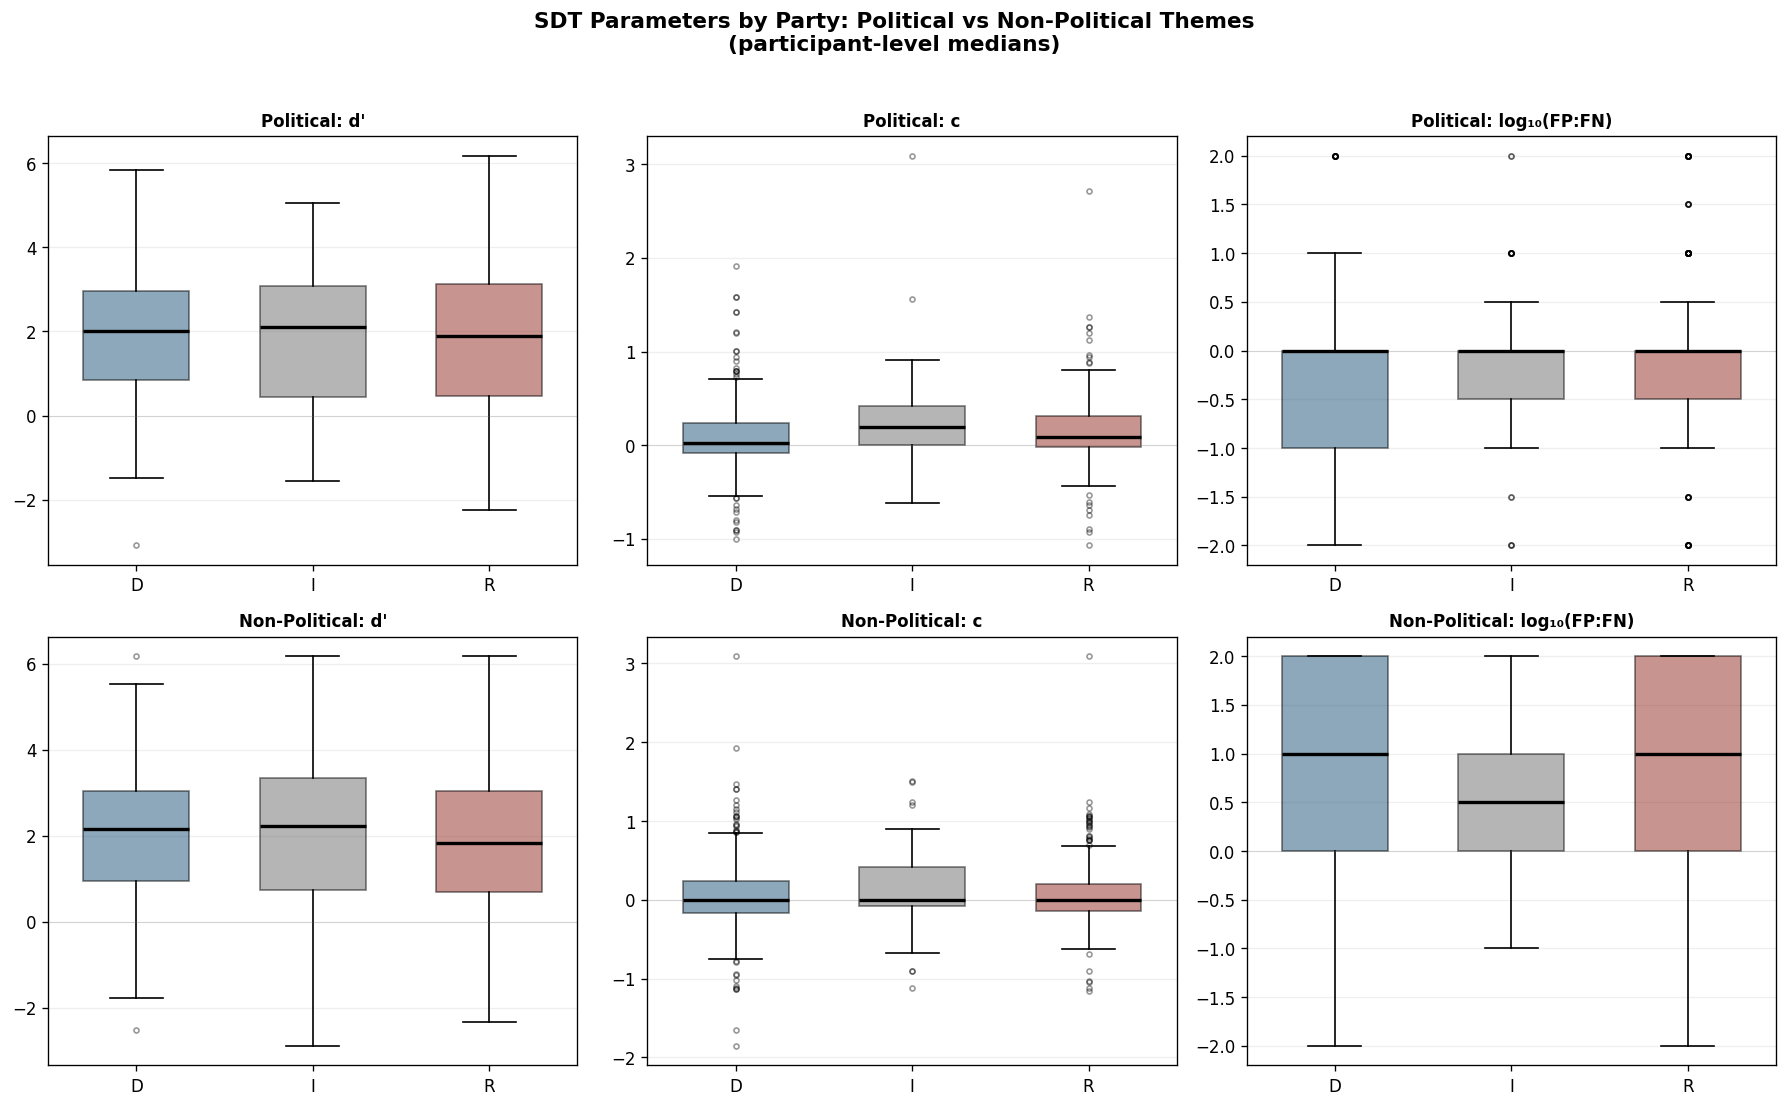

In [22]:
# Boxplot: Political vs Non-Political, by party
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for col_idx, (var, label) in enumerate([('d_prime', "d'"), ('c_sdt', 'c'),
                                         ('log_ratio', 'log₁₀(FP:FN)')]):
    for row_idx, (group_label, theme_list) in enumerate(
            [('Political', POLITICAL_THEMES), ('Non-Political', NONPOLITICAL_THEMES)]):
        ax = axes[row_idx, col_idx]
        subset = long[long['theme'].isin(theme_list)].dropna(subset=[var])

        # Participant-level median
        part_agg = subset.groupby(['respondent_id', 'party_binary'])[var].median().reset_index()

        box_data = []
        box_colors = []
        for party in ['Democrat', 'Independent', 'Republican']:
            pdata = part_agg[part_agg['party_binary'] == party][var]
            box_data.append(pdata.values if len(pdata) > 0 else [])
            box_colors.append(PARTY_COLORS[party])

        bp = ax.boxplot(box_data, positions=[0, 1, 2], widths=0.6,
                       patch_artist=True, showfliers=True,
                       flierprops={'markersize': 3, 'alpha': 0.4})
        for patch, color in zip(bp['boxes'], box_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.5)
        for median_line in bp['medians']:
            median_line.set_color('black')
            median_line.set_linewidth(2)

        ax.set_xticks([0, 1, 2])
        ax.set_xticklabels(['D', 'I', 'R'])
        ax.set_title(f'{group_label}: {label}', fontweight='bold', fontsize=10)
        ax.axhline(0, color='gray', linewidth=0.5, alpha=0.3)
        ax.grid(axis='y', alpha=0.2)

fig.suptitle('SDT Parameters by Party: Political vs Non-Political Themes\n'
             '(participant-level medians)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [23]:
print("\n" + "=" * 70)
print("BUNDLED ANALYSIS: R-FN-WORSE vs R-FP-WORSE THEMES")
print("=" * 70)
print(f"  R thinks FN worse (miss=letting threats through): {R_FN_WORSE}")
print(f"  R thinks FP worse (FP=wrongly restricting access): {R_FP_WORSE}")

for var, label in [('log_ratio', 'log_ratio'), ('log_ratio_aligned', 'log_ratio_aligned')]:
    print(f"\n--- {label} ---")
    for group_label, theme_list in [('R:FN-worse', R_FN_WORSE),
                                     ('R:FP-worse', R_FP_WORSE)]:
        subset = long[long['theme'].isin(theme_list)]
        part_agg = subset.groupby(['respondent_id', 'party_binary'])[var].median().reset_index()

        for party in ['Democrat', 'Republican']:
            pdata = part_agg[part_agg['party_binary'] == party][var].dropna()
            if len(pdata) > 0:
                print(f"  {group_label:<15} {party:<12} n={len(pdata):>4}  "
                      f"median={pdata.median():>7.3f}  mean={pdata.mean():>7.3f}")


BUNDLED ANALYSIS: R-FN-WORSE vs R-FP-WORSE THEMES
  R thinks FN worse (miss=letting threats through): ['armed', 'conv', 'immi', 'vote']
  R thinks FP worse (FP=wrongly restricting access): ['firearm']

--- log_ratio ---
  R:FN-worse      Democrat     n= 313  median=  0.000  mean= -0.442
  R:FN-worse      Republican   n= 212  median=  0.000  mean= -0.075
  R:FP-worse      Democrat     n= 179  median=  1.000  mean=  0.709
  R:FP-worse      Republican   n= 145  median= -0.000  mean=  0.524

--- log_ratio_aligned ---
  R:FN-worse      Democrat     n= 313  median=  0.000  mean= -0.442
  R:FN-worse      Republican   n= 212  median=  0.000  mean= -0.075
  R:FP-worse      Democrat     n= 179  median= -1.000  mean= -0.709
  R:FP-worse      Republican   n= 145  median= -0.000  mean= -0.524


## Summary Notes

**Key things to check in the output above:**

1. **Kurtosis**: Which themes have leptokurtic (peaked) distributions?
   High kurtosis in neutral themes (disease, auto) with low kurtosis in
   politically live themes (immigration, voting) would suggest political
   engagement inflates variance.

2. **Skewness**: Which distributions are asymmetric? If FPR or TPR beliefs
   pile up near 0 or 1, the z-transform for d' amplifies extreme values.

3. **Median vs Mean divergence**: Large gaps signal outlier sensitivity.
   If mean ≠ median, the pooled ROC plots (which currently use means)
   should switch to medians.

4. **Below-diagonal cross-theme correlation**: If positive, it's a trait
   (some people consistently misunderstand the task). If near zero,
   it's noise and shouldn't drive additional exclusions.

5. **Political vs Non-Political**: If the D–R gap is larger for political
   themes on c but not d', that supports the paper's core argument
   (partisans disagree about thresholds, not sensitivity).